# Independent-angle double-layer Sobol 64 report

6개 독립 설계변수로 수행한 64개 FEMM 해석 결과를 점검하고, 평균토크 최대화와 토크리플 최소화 관점에서 우수 후보를 비교한다.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

current_dir = Path.cwd().resolve()
project_root = current_dir.parent if current_dir.name == 'analysis_results' else current_dir
csv_path = project_root / 'independent_angle_sobol_64_results' / 'independent_angle_summary.csv'
if not csv_path.exists():
    raise FileNotFoundError(f'Result CSV not found: {csv_path}')
df = pd.read_csv(csv_path)
print(f'파일: {csv_path.resolve()}')
print(f'행 {len(df):,}개, 열 {df.shape[1]:,}개')
display(df.head(3))

파일: C:\Users\139\Documents\pyFEMM 2\independent_angle_sobol_64_results\independent_angle_summary.csv
행 64개, 열 35개


,run,candidate,inner_angle_deg,outer_angle_deg,outer_area_ratio,inner_thickness_mm,inner_length_mm,layer_normal_gap_mm,angle_difference_deg,outer_length_mm,outer_thickness_mm,inner_center_radius_mm,outer_center_radius_mm,inner_center_offset_deg,outer_center_offset_deg,outer_bridge_min_mm,shaft_clearance_min_mm,layer_gap_actual_min_mm,other_magnet_gap_min_mm,geometry_status,exact_outer_bridge_min_mm,exact_shaft_clearance_min_mm,exact_layer_gap_actual_min_mm,exact_other_magnet_gap_min_mm,theta_start_deg,theta_stop_deg,theta_step_deg,current_peak_A,commutation_offset_deg,completed_points,loaded_torque_mean_Nm,loaded_torque_min_Nm,loaded_torque_max_Nm,loaded_torque_pkpk_Nm,loaded_torque_ripple_pct
0,1,1,45.8761,56.6586,0.7044,2.4258,16.3712,1.0816,10.7825,13.7404,2.0360,18.0000,23.6376,20.0791,14.8128,1.2631,1.5223,1.0816,0.6076,OK,1.2631,1.5223,1.0816,0.6075,0,28,2,10,35,15,43.0816,36.8015,49.5219,12.7204,29.5263
1,2,2,87.0123,89.7150,0.6452,1.8217,15.0493,1.6819,2.7027,12.0886,1.4633,18.0000,20.7451,25.7436,17.8182,7.5355,6.9123,1.6819,0.5104,OK,7.5355,6.9123,1.6819,0.5104,0,28,2,10,35,15,28.5326,26.4921,29.8625,3.3704,11.8124
2,3,3,65.2097,64.7983,0.7978,2.5782,15.2083,1.5047,-0.4114,13.5844,2.3029,18.0000,21.5362,23.6031,17.4256,3.7629,3.8897,1.5047,0.6075,OK,3.7629,3.8897,1.5047,0.6075,0,28,2,10,35,15,43.9441,39.2047,48.6006,9.3960,21.3816


## 1. 계산 완전성 및 상태 점검

In [2]:
expected_runs = set(range(1, 65))
actual_runs = set(pd.to_numeric(df['run'], errors='coerce').dropna().astype(int))
missing_runs = sorted(expected_runs - actual_runs)
duplicate_runs = sorted(df.loc[df['run'].duplicated(keep=False), 'run'].unique())
status_counts = df['geometry_status'].fillna('MISSING').value_counts().rename_axis('geometry_status').to_frame('count')

checks = pd.Series({
    'expected_runs': 64,
    'rows_in_summary': len(df),
    'unique_runs': df['run'].nunique(),
    'missing_runs': missing_runs or 'none',
    'duplicate_runs': duplicate_runs or 'none',
    'rows_with_15_completed_points': int((df['completed_points'] == 15).sum()),
    'missing_cells': int(df.isna().sum().sum()),
})
display(checks.to_frame('value'))
display(status_counts)

,value
expected_runs,64
rows_in_summary,64
unique_runs,64
missing_runs,none
duplicate_runs,none
rows_with_15_completed_points,64
missing_cells,0


,count
geometry_status,
OK,64


## 2. 6개 설계변수와 응답 통계

In [3]:
variables = [
    'inner_angle_deg', 'outer_angle_deg', 'outer_area_ratio',
    'inner_thickness_mm', 'inner_length_mm', 'layer_normal_gap_mm'
]
responses = ['loaded_torque_mean_Nm', 'loaded_torque_ripple_pct', 'loaded_torque_pkpk_Nm']
valid = df.loc[(df['geometry_status'] == 'OK') & (df['completed_points'] == 15)].copy()
display(valid[variables + responses].describe().T)
print(f'분석에 사용한 정상 완료점: {len(valid)}/{len(df)}')

,count,mean,std,min,25%,50%,75%,max
inner_angle_deg,64.0000,64.6703,13.9751,41.1289,53.3235,64.4058,76.8115,89.0768
outer_angle_deg,64.0000,70.8052,11.5220,51.0207,60.8337,71.0176,80.6747,89.7150
outer_area_ratio,64.0000,0.6471,0.0863,0.5033,0.5705,0.6462,0.7144,0.7978
inner_thickness_mm,64.0000,2.2340,0.2824,1.7542,2.0072,2.2345,2.4688,2.7390
inner_length_mm,64.0000,15.6129,0.6793,14.5221,15.0430,15.5837,16.1833,16.7884
layer_normal_gap_mm,64.0000,1.2527,0.4392,0.5089,0.8733,1.2514,1.6203,1.9939
loaded_torque_mean_Nm,64.0000,40.0258,5.7705,24.2943,36.1200,39.9700,43.1199,56.4903
loaded_torque_ripple_pct,64.0000,19.6840,7.5589,6.3417,13.5138,19.8522,25.7735,37.3661
loaded_torque_pkpk_Nm,64.0000,8.0483,3.6776,1.9092,5.2739,8.0009,10.4788,19.1264


분석에 사용한 정상 완료점: 64/64


## 2-1. DOE 입력공간 품질검사

응답 히스토그램의 정규성은 DOE 품질 기준이 아니다. 실제 64개 입력점의 공간충진성, 점간거리, 투영 균형과 변수 간 상관을 이상적인 64점 Sobol 및 무작위 표본과 비교한다.

,actual_64,ideal_sobol_64,random_median,random_5pct,random_95pct
centered_discrepancy,0.0092,0.0054,0.0325,0.0231,0.0496
minimum_pair_distance,0.2954,0.2954,0.2136,0.1289,0.2806
mean_nearest_distance,0.4638,0.4655,0.4165,0.3922,0.4407
max_abs_spearman,0.1503,0.0469,0.2516,0.1726,0.3674
max_8bin_count_deviation,2.0000,0.0000,6.0000,5.0000,9.0000


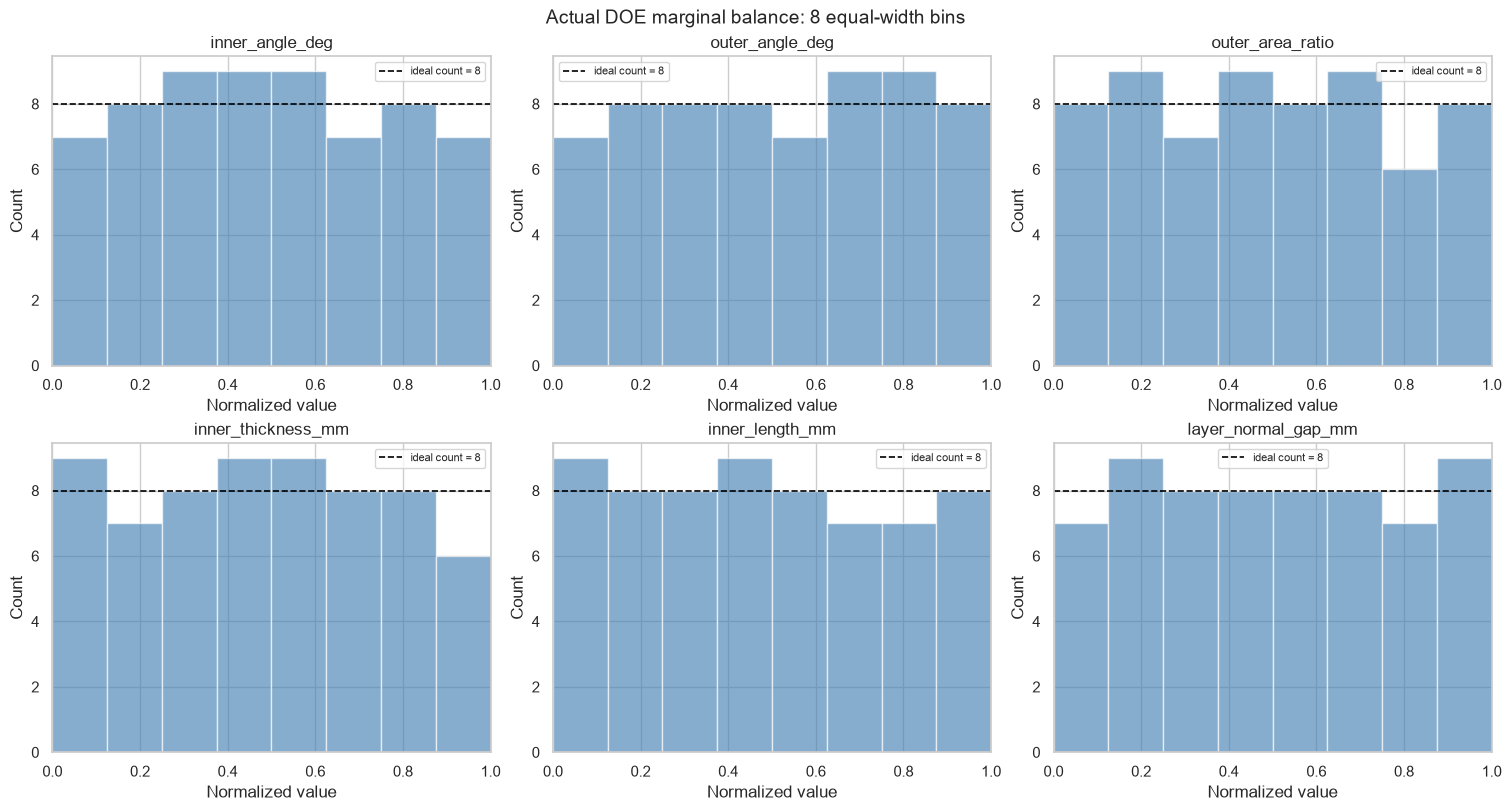

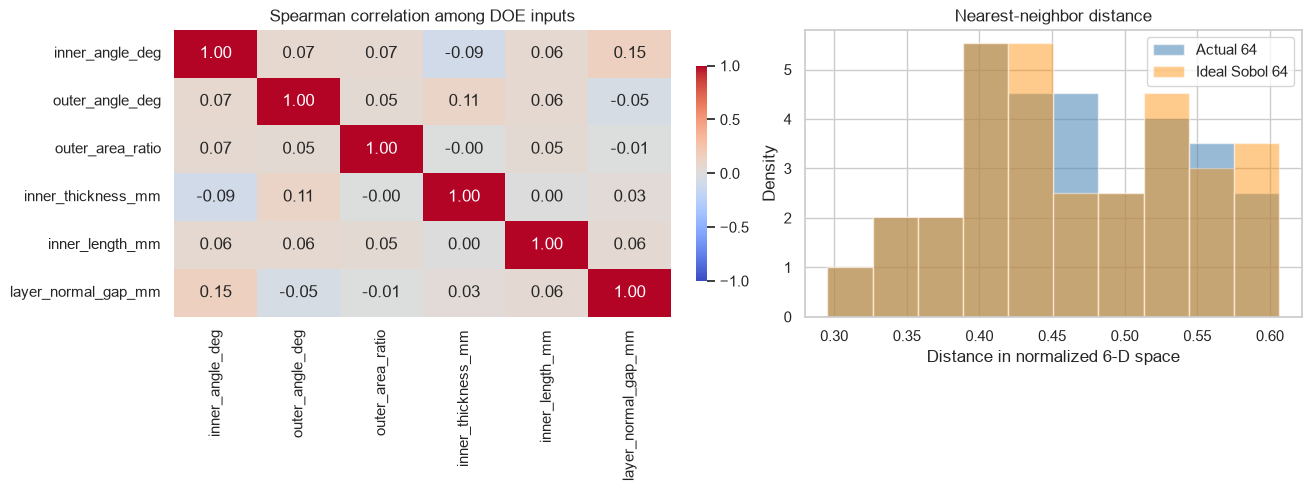

In [4]:
from scipy.stats import qmc
from scipy.spatial.distance import pdist, squareform

doe_bounds = {
    'inner_angle_deg': (40.0, 90.0),
    'outer_angle_deg': (50.0, 90.0),
    'outer_area_ratio': (0.50, 0.80),
    'inner_thickness_mm': (1.75, 2.75),
    'inner_length_mm': (14.5, 16.8),
    'layer_normal_gap_mm': (0.5, 2.0),
}
lower = np.array([doe_bounds[name][0] for name in variables])
upper = np.array([doe_bounds[name][1] for name in variables])
x_actual = (valid[variables].to_numpy() - lower) / (upper - lower)
x_ideal = qmc.Sobol(d=len(variables), scramble=True, seed=20260803).random_base2(6)

def design_metrics(points):
    distances = squareform(pdist(points))
    np.fill_diagonal(distances, np.inf)
    nearest = distances.min(axis=1)
    corr = pd.DataFrame(points).corr(method='spearman').to_numpy()
    off_diag = np.abs(corr[np.triu_indices_from(corr, k=1)])
    bins = np.stack([np.histogram(points[:, j], bins=np.linspace(0, 1, 9))[0] for j in range(points.shape[1])])
    return {
        'centered_discrepancy': qmc.discrepancy(points, method='CD'),
        'minimum_pair_distance': pdist(points).min(),
        'mean_nearest_distance': nearest.mean(),
        'max_abs_spearman': off_diag.max(),
        'max_8bin_count_deviation': np.abs(bins - points.shape[0] / 8).max(),
    }, nearest

actual_metrics, actual_nearest = design_metrics(x_actual)
ideal_metrics, ideal_nearest = design_metrics(x_ideal)
rng = np.random.default_rng(20260803)
random_metrics = pd.DataFrame([design_metrics(rng.random((64, len(variables))))[0] for _ in range(500)])
quality_table = pd.DataFrame({
    'actual_64': actual_metrics,
    'ideal_sobol_64': ideal_metrics,
    'random_median': random_metrics.median(),
    'random_5pct': random_metrics.quantile(0.05),
    'random_95pct': random_metrics.quantile(0.95),
})
display(quality_table.round(5))

fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
for index, (name, ax) in enumerate(zip(variables, axes.flat)):
    ax.hist(x_actual[:, index], bins=np.linspace(0, 1, 9), color='steelblue', alpha=0.65, edgecolor='white')
    ax.axhline(8, color='black', linestyle='--', linewidth=1.2, label='ideal count = 8')
    ax.set(title=name, xlabel='Normalized value', ylabel='Count', xlim=(0, 1))
    ax.legend(fontsize=8)
fig.suptitle('Actual DOE marginal balance: 8 equal-width bins', fontsize=14);

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
corr_actual = pd.DataFrame(x_actual, columns=variables).corr(method='spearman')
sns.heatmap(corr_actual, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=axes[0], cbar_kws={'shrink': 0.75})
axes[0].set_title('Spearman correlation among DOE inputs')
axes[1].hist(actual_nearest, bins=10, alpha=0.55, label='Actual 64', color='steelblue', density=True)
axes[1].hist(ideal_nearest, bins=10, alpha=0.45, label='Ideal Sobol 64', color='darkorange', density=True)
axes[1].set(title='Nearest-neighbor distance', xlabel='Distance in normalized 6-D space', ylabel='Density')
axes[1].legend();

### DOE 품질 판정 기준

- `centered_discrepancy`는 작을수록 전체 공간을 고르게 채운다.
- 점간거리가 지나치게 작으면 설계점이 뭉쳐 있다.
- `max_abs_spearman`이 크면 입력변수 사이에 의도하지 않은 상관이 생긴 것이다.
- 각 변수의 8개 구간에는 이상적으로 8점씩 들어간다. 형상 탈락점 대체로 실제 설계는 완전한 Sobol 균형에서 일부 벗어날 수 있다.
- 최종 평가는 입력공간 지표와 후속 GP 교차검증 오차를 함께 사용한다.

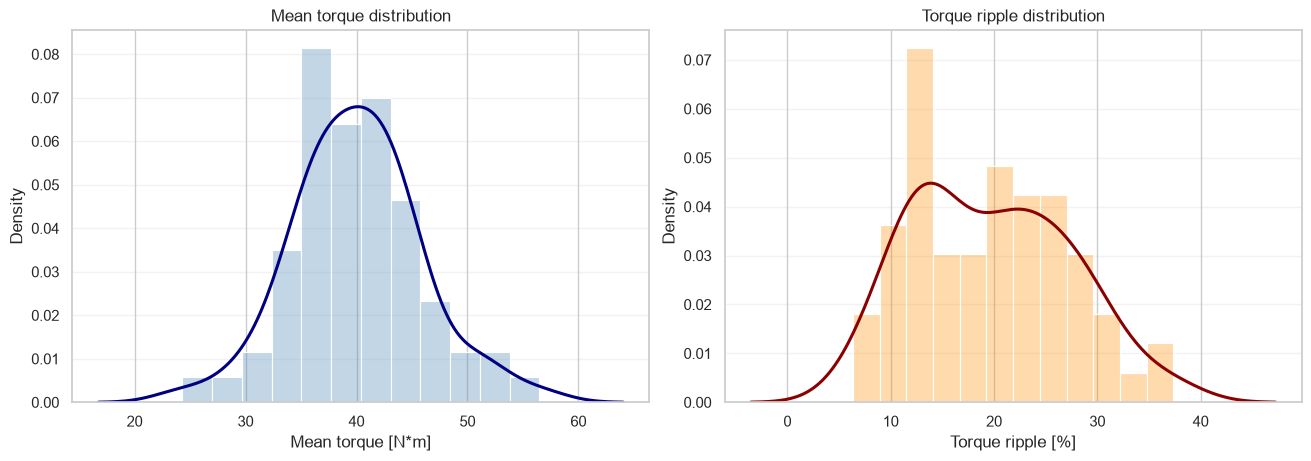

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

sns.histplot(
    valid['loaded_torque_mean_Nm'], bins=12, stat='density', ax=axes[0],
    color='steelblue', alpha=0.32, edgecolor='white', linewidth=0.8
)
sns.kdeplot(valid['loaded_torque_mean_Nm'], ax=axes[0], color='navy', linewidth=2.2)
axes[0].set(title='Mean torque distribution', xlabel='Mean torque [N*m]', ylabel='Density')
axes[0].grid(axis='y', alpha=0.25)

sns.histplot(
    valid['loaded_torque_ripple_pct'], bins=12, stat='density', ax=axes[1],
    color='darkorange', alpha=0.32, edgecolor='white', linewidth=0.8
)
sns.kdeplot(valid['loaded_torque_ripple_pct'], ax=axes[1], color='darkred', linewidth=2.2)
axes[1].set(title='Torque ripple distribution', xlabel='Torque ripple [%]', ylabel='Density')
axes[1].grid(axis='y', alpha=0.25);

### 자석 사용량 대비 평균토크 밀도

각 자석의 실제 단면적을 `length × normal_thickness / |sin(angle)|`로 계산하고, 회전자 전체 8개 내측 자석과 8개 외측 자석의 합계로 평균토크를 나눈다.

,count,mean,std,min,25%,50%,75%,max
total_magnet_area_mm2,64.0000,518.7525,85.0328,361.1294,455.5379,509.8585,579.9521,726.7770
torque_per_magnet_area_Nm_per_mm2,64.0000,0.0781,0.0106,0.0510,0.0724,0.0777,0.0846,0.1029


,run,inner_angle_deg,outer_angle_deg,outer_area_ratio,total_magnet_area_mm2,loaded_torque_mean_Nm,loaded_torque_ripple_pct,torque_per_magnet_area_Nm_per_mm2
58,59,87.9453,62.9197,0.5711,426.3259,43.8805,13.4161,0.1029
14,15,83.8658,65.4758,0.7066,521.2844,51.7987,20.8364,0.0994
43,44,70.2252,77.9129,0.7451,419.5401,41.3479,13.5464,0.0986
25,26,71.2939,67.9107,0.5433,375.1044,36.0153,9.8387,0.0960
28,29,67.9647,70.4691,0.6099,452.3795,41.6771,12.1484,0.0921
9,10,80.5303,72.9173,0.7361,469.9429,43.2350,13.2062,0.0920
60,61,88.0594,76.4802,0.7669,615.0131,56.4903,28.5625,0.0919
46,47,84.7987,82.4274,0.7895,419.9123,38.2616,11.4904,0.0911
55,56,53.5571,83.6176,0.5255,369.2745,33.3392,25.7310,0.0903
11,12,55.7264,86.0176,0.6795,456.5907,40.8291,26.3691,0.0894


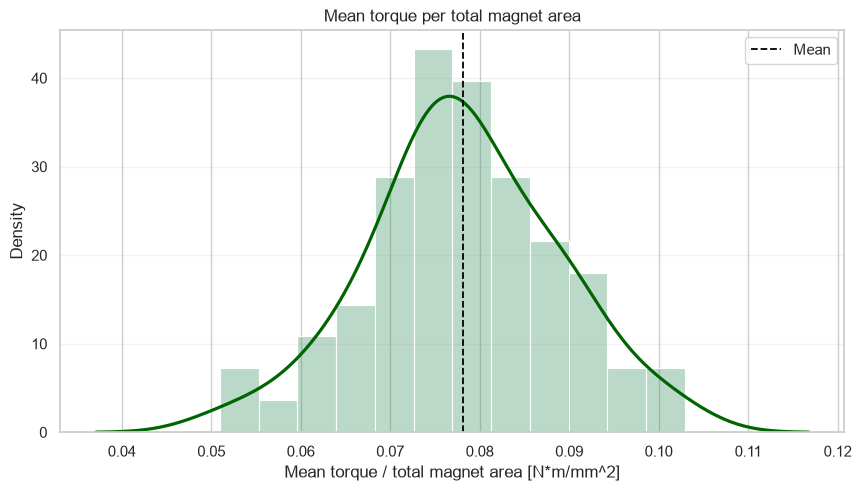

In [6]:
efficiency_view = valid.copy()
inner_area_one = (
    efficiency_view['inner_length_mm'] * efficiency_view['inner_thickness_mm']
    / np.abs(np.sin(np.deg2rad(efficiency_view['inner_angle_deg'])))
)
outer_area_one = (
    efficiency_view['outer_length_mm'] * efficiency_view['outer_thickness_mm']
    / np.abs(np.sin(np.deg2rad(efficiency_view['outer_angle_deg'])))
)
efficiency_view['total_magnet_area_mm2'] = 8 * (inner_area_one + outer_area_one)
efficiency_view['torque_per_magnet_area_Nm_per_mm2'] = (
    efficiency_view['loaded_torque_mean_Nm'] / efficiency_view['total_magnet_area_mm2']
)

fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
sns.histplot(
    efficiency_view['torque_per_magnet_area_Nm_per_mm2'],
    bins=12, stat='density', color='seagreen', alpha=0.32,
    edgecolor='white', linewidth=0.8, ax=ax
)
sns.kdeplot(
    efficiency_view['torque_per_magnet_area_Nm_per_mm2'],
    color='darkgreen', linewidth=2.3, ax=ax
)
ax.axvline(
    efficiency_view['torque_per_magnet_area_Nm_per_mm2'].mean(),
    color='black', linestyle='--', linewidth=1.3, label='Mean'
)
ax.set(
    title='Mean torque per total magnet area',
    xlabel='Mean torque / total magnet area [N*m/mm^2]',
    ylabel='Density'
)
ax.grid(axis='y', alpha=0.25)
ax.legend();

display(
    efficiency_view[[
        'total_magnet_area_mm2', 'torque_per_magnet_area_Nm_per_mm2'
    ]].describe().T.round(5)
)
display(
    efficiency_view.sort_values('torque_per_magnet_area_Nm_per_mm2', ascending=False)[[
        'run', 'inner_angle_deg', 'outer_angle_deg', 'outer_area_ratio',
        'total_magnet_area_mm2', 'loaded_torque_mean_Nm',
        'loaded_torque_ripple_pct', 'torque_per_magnet_area_Nm_per_mm2'
    ]].head(10).round(5)
)

## 3. 상관관계 분석

DNN 학습 전에 설계변수와 응답의 단조 관계를 Spearman 상관계수로 확인한다. 이 결과는 민감도가 아니며 다른 변수의 영향을 통제하지 않은 탐색 분석이다.

,loaded_torque_mean_Nm,loaded_torque_ripple_pct,torque_per_magnet_area_Nm_per_mm2
inner_angle_deg,-0.0914,-0.8179,0.4175
outer_angle_deg,0.3242,0.0722,0.3897
outer_area_ratio,0.3977,0.2167,0.1098
inner_thickness_mm,0.4364,0.2194,-0.4482
inner_length_mm,0.6201,-0.0387,0.4360
layer_normal_gap_mm,0.0960,-0.0285,0.0833


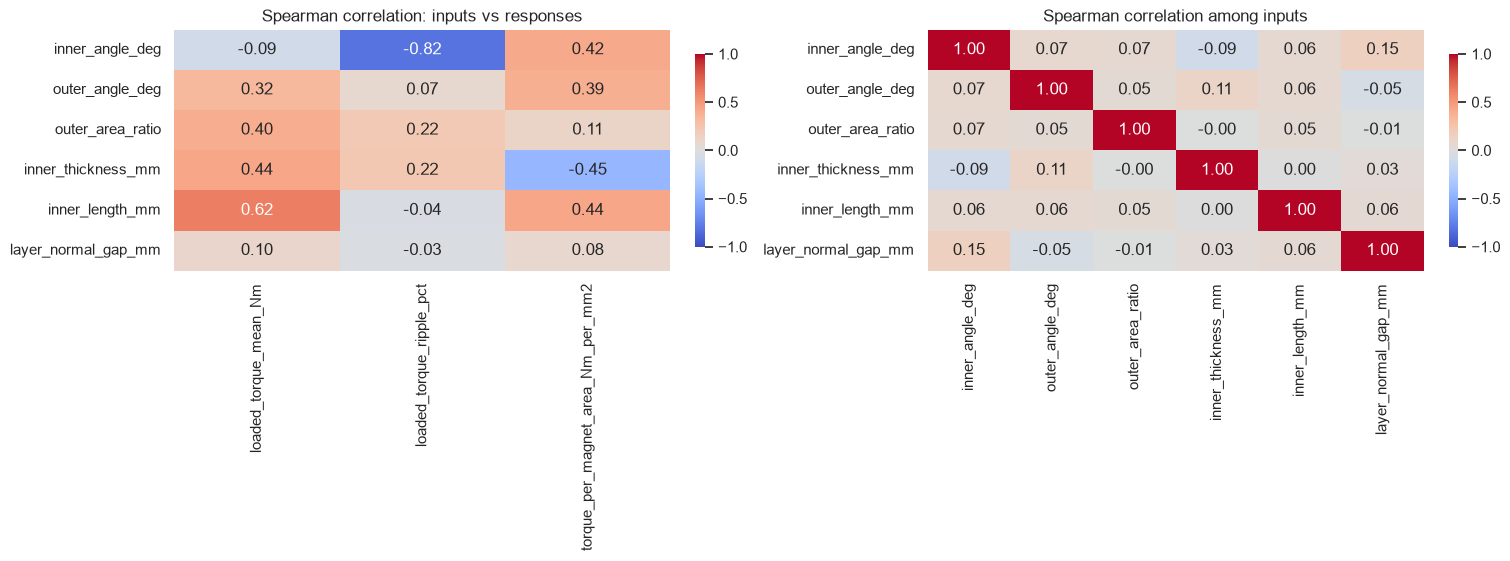

In [7]:
correlation_targets = [
    'loaded_torque_mean_Nm',
    'loaded_torque_ripple_pct',
    'torque_per_magnet_area_Nm_per_mm2',
]
correlation_data = efficiency_view[variables + correlation_targets].copy()
spearman_all = correlation_data.corr(method='spearman')
display(spearman_all.loc[variables, correlation_targets].round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
sns.heatmap(
    spearman_all.loc[variables, correlation_targets], annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=axes[0],
    cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Spearman correlation: inputs vs responses')
sns.heatmap(
    correlation_data[variables].corr(method='spearman'), annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=axes[1],
    cbar_kws={'shrink': 0.8}
)
axes[1].set_title('Spearman correlation among inputs');

## 4. DNN 대리모델 학습 및 검증

상관관계 확인 후 6개 독립 설계변수로 평균토크, 토크리플과 자석 사용량 대비 토크를 예측하는 DNN을 학습한다. 반복 교차검증의 MAE, RMSE와 R²가 충분한지 확인하기 전에는 대규모 후보 예측과 최종 Pareto 선정을 수행하지 않는다.

아래 셀은 반복 5-fold 교차검증으로 실제 성능을 평가하고, 전체 데이터로 여러 seed의 DNN 앙상블을 학습한다. 64점 실측 Pareto는 예비 결과로만 표시한다.

,MAE,RMSE,R2
target,,,
loaded_torque_mean_Nm,2.5744,3.4460,0.6377
loaded_torque_ripple_pct,2.9827,4.1620,0.6920
torque_per_magnet_area_Nm_per_mm2,0.0054,0.0070,0.5603


Trained DNN ensemble: 12 models


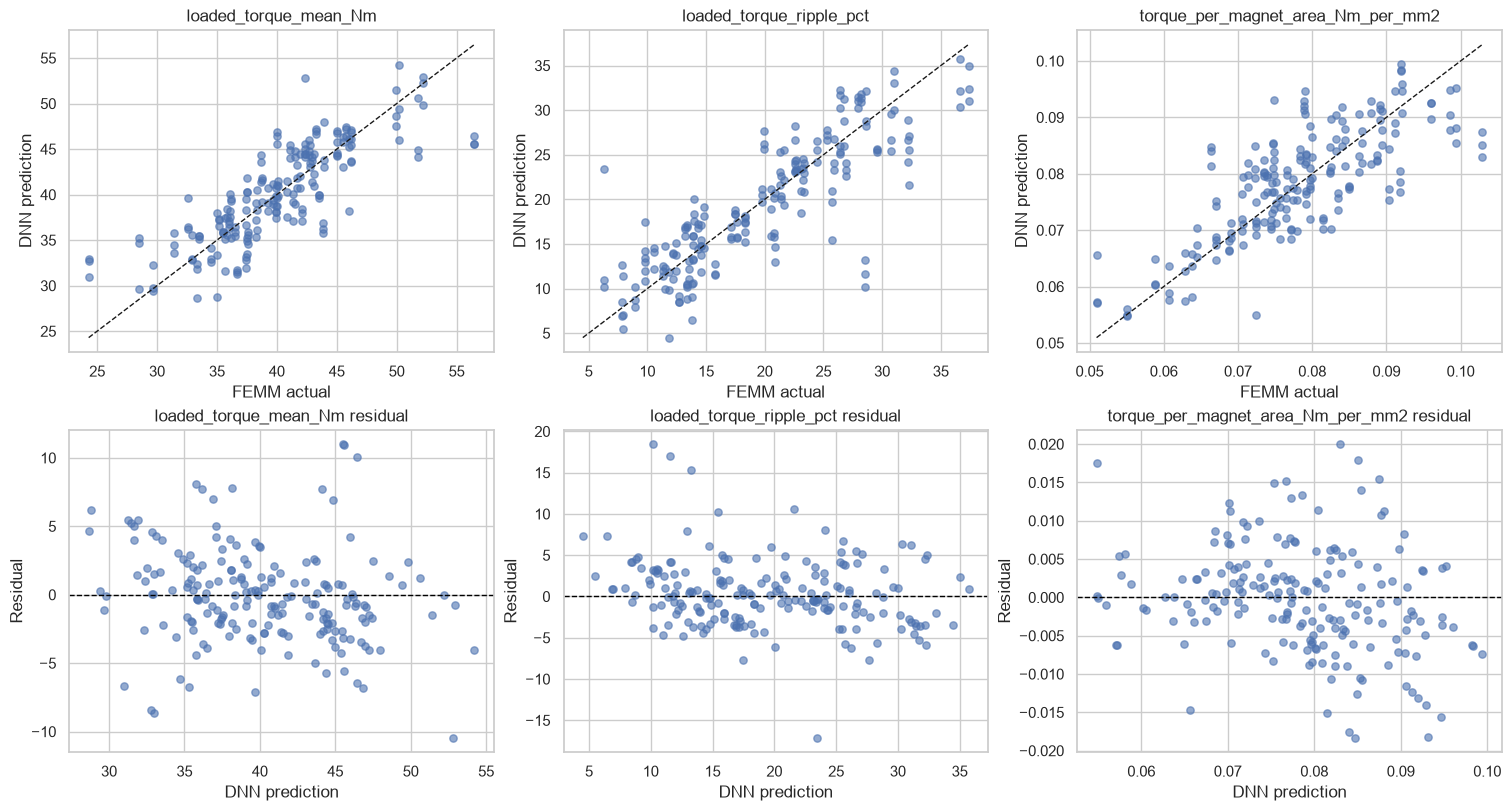

In [8]:
from sklearn.model_selection import RepeatedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
from sklearn.exceptions import ConvergenceWarning

dnn_targets = [
    'loaded_torque_mean_Nm',
    'loaded_torque_ripple_pct',
    'torque_per_magnet_area_Nm_per_mm2',
]
X_dnn = efficiency_view[variables].to_numpy()
y_dnn = efficiency_view[dnn_targets].to_numpy()
rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=20260804)
oof_true, oof_pred = [], []
with warnings.catch_warnings():
    warnings.simplefilter('ignore', ConvergenceWarning)
    for fold, (train_idx, test_idx) in enumerate(rkf.split(X_dnn)):
        x_scaler_fold = StandardScaler().fit(X_dnn[train_idx])
        y_scaler_fold = StandardScaler().fit(y_dnn[train_idx])
        model_fold = MLPRegressor(
            hidden_layer_sizes=(16, 8), activation='tanh', solver='lbfgs',
            alpha=0.3, max_iter=3000, random_state=20260804 + fold
        )
        model_fold.fit(
            x_scaler_fold.transform(X_dnn[train_idx]),
            y_scaler_fold.transform(y_dnn[train_idx]),
        )
        fold_pred = y_scaler_fold.inverse_transform(
            model_fold.predict(x_scaler_fold.transform(X_dnn[test_idx]))
        )
        oof_true.append(y_dnn[test_idx])
        oof_pred.append(fold_pred)
oof_true = np.vstack(oof_true)
oof_pred = np.vstack(oof_pred)
dnn_cv_metrics = pd.DataFrame([
    {
        'target': target,
        'MAE': mean_absolute_error(oof_true[:, j], oof_pred[:, j]),
        'RMSE': mean_squared_error(oof_true[:, j], oof_pred[:, j]) ** 0.5,
        'R2': r2_score(oof_true[:, j], oof_pred[:, j]),
    }
    for j, target in enumerate(dnn_targets)
]).set_index('target')
display(dnn_cv_metrics.round(5))

fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
for j, target in enumerate(dnn_targets):
    axes[0, j].scatter(oof_true[:, j], oof_pred[:, j], alpha=0.6, s=28)
    lo_j = min(oof_true[:, j].min(), oof_pred[:, j].min())
    hi_j = max(oof_true[:, j].max(), oof_pred[:, j].max())
    axes[0, j].plot([lo_j, hi_j], [lo_j, hi_j], 'k--', linewidth=1)
    axes[0, j].set(title=target, xlabel='FEMM actual', ylabel='DNN prediction')
    residual = oof_true[:, j] - oof_pred[:, j]
    axes[1, j].scatter(oof_pred[:, j], residual, alpha=0.6, s=28)
    axes[1, j].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[1, j].set(xlabel='DNN prediction', ylabel='Residual', title=f'{target} residual')

x_scaler_dnn = StandardScaler().fit(X_dnn)
y_scaler_dnn = StandardScaler().fit(y_dnn)
dnn_models = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore', ConvergenceWarning)
    for seed in range(12):
        model = MLPRegressor(
            hidden_layer_sizes=(16, 8), activation='tanh', solver='lbfgs',
            alpha=0.3, max_iter=3000, random_state=20260900 + seed
        )
        model.fit(x_scaler_dnn.transform(X_dnn), y_scaler_dnn.transform(y_dnn))
        dnn_models.append(model)

def dnn_predict(points):
    scaled = x_scaler_dnn.transform(np.asarray(points))
    predictions = np.stack([
        y_scaler_dnn.inverse_transform(model.predict(scaled))
        for model in dnn_models
    ])
    return predictions.mean(axis=0), predictions.std(axis=0)

print(f'Trained DNN ensemble: {len(dnn_models)} models')

### Gaussian Process/Kriging 비교

64점처럼 작은 고비용 해석 데이터에는 DNN보다 GP가 적합할 수 있다. DNN과 동일한 반복 5-fold 분할로 GP를 검증하고, 응답별 R²가 기준을 통과하는지 확인한다.

DNN               GP_Kriging         \
                                     MAE   RMSE     R2        MAE   RMSE   
target                                                                     
loaded_torque_mean_Nm             2.5744 3.4460 0.6377     1.4194 2.0064   
loaded_torque_ripple_pct          2.9827 4.1620 0.6920     2.4571 3.4507   
torque_per_magnet_area_Nm_per_mm2 0.0054 0.0070 0.5603     0.0029 0.0041   

                                          
                                      R2  
target                                    
loaded_torque_mean_Nm             0.8772  
loaded_torque_ripple_pct          0.7883  
torque_per_magnet_area_Nm_per_mm2 0.8508

,R2_gate_pass
target,
loaded_torque_mean_Nm,True
loaded_torque_ripple_pct,False
torque_per_magnet_area_Nm_per_mm2,True


All-response GP gate: False


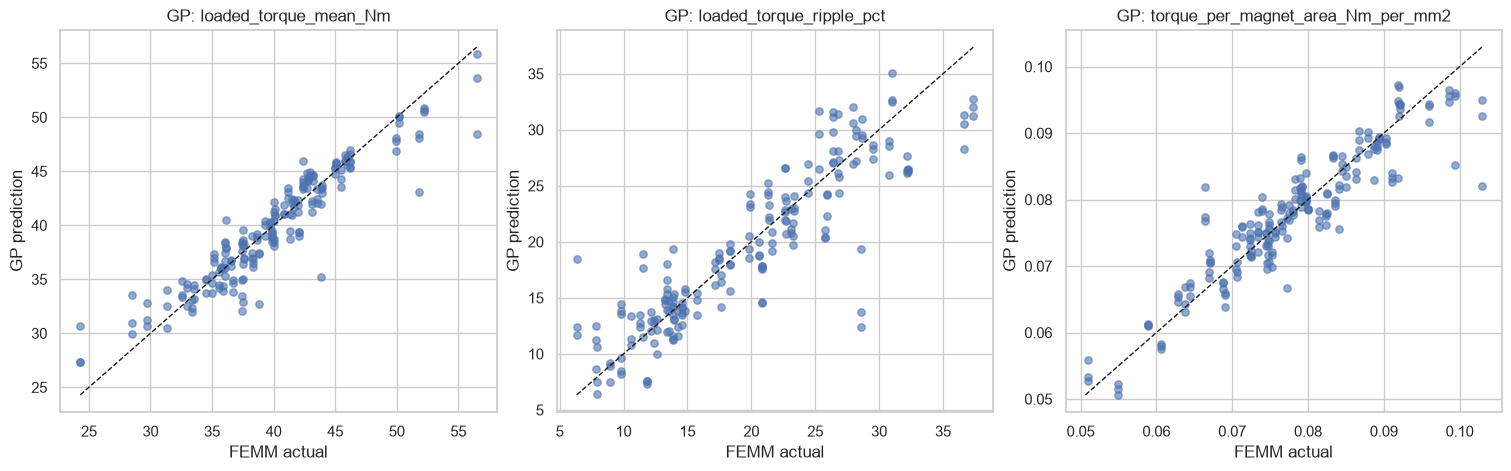

In [9]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

def gp_kernel_for_target(target):
    nu = 1.5 if target == 'loaded_torque_ripple_pct' else 2.5
    return (
        ConstantKernel(1.0, (1e-2, 1e2))
        * Matern(length_scale=np.ones(len(variables)), length_scale_bounds=(1e-2, 1e2), nu=nu)
        + WhiteKernel(1e-3, (1e-6, 1e0))
    )

gp_oof_true = [[] for _ in dnn_targets]
gp_oof_pred = [[] for _ in dnn_targets]
with warnings.catch_warnings():
    warnings.simplefilter('ignore', ConvergenceWarning)
    for fold, (train_idx, test_idx) in enumerate(rkf.split(X_dnn)):
        scaler_fold = StandardScaler().fit(X_dnn[train_idx])
        x_train_fold = scaler_fold.transform(X_dnn[train_idx])
        x_test_fold = scaler_fold.transform(X_dnn[test_idx])
        for j, target in enumerate(dnn_targets):
            gp_fold = GaussianProcessRegressor(
                kernel=gp_kernel_for_target(target), normalize_y=True,
                n_restarts_optimizer=2, random_state=20261000 + fold + j,
            )
            gp_fold.fit(x_train_fold, y_dnn[train_idx, j])
            gp_oof_true[j].append(y_dnn[test_idx, j])
            gp_oof_pred[j].append(gp_fold.predict(x_test_fold))
gp_cv_rows = []
for j, target in enumerate(dnn_targets):
    actual_j = np.concatenate(gp_oof_true[j])
    pred_j = np.concatenate(gp_oof_pred[j])
    gp_cv_rows.append({
        'target': target,
        'MAE': mean_absolute_error(actual_j, pred_j),
        'RMSE': mean_squared_error(actual_j, pred_j) ** 0.5,
        'R2': r2_score(actual_j, pred_j),
    })
gp_cv_metrics = pd.DataFrame(gp_cv_rows).set_index('target')
surrogate_comparison = pd.concat(
    {'DNN': dnn_cv_metrics, 'GP_Kriging': gp_cv_metrics}, axis=1
)
display(surrogate_comparison.round(5))

gp_r2_threshold = 0.85
gp_gate = gp_cv_metrics['R2'] >= gp_r2_threshold
display(gp_gate.rename('R2_gate_pass').to_frame())
print('All-response GP gate:', bool(gp_gate.all()))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), constrained_layout=True)
for j, target in enumerate(dnn_targets):
    actual_j = np.concatenate(gp_oof_true[j])
    pred_j = np.concatenate(gp_oof_pred[j])
    axes[j].scatter(actual_j, pred_j, alpha=0.6, s=28)
    lo_j = min(actual_j.min(), pred_j.min())
    hi_j = max(actual_j.max(), pred_j.max())
    axes[j].plot([lo_j, hi_j], [lo_j, hi_j], 'k--', linewidth=1)
    axes[j].set(title=f'GP: {target}', xlabel='FEMM actual', ylabel='GP prediction')

x_scaler_gp = StandardScaler().fit(X_dnn)
gp_models = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore', ConvergenceWarning)
    for j, target in enumerate(dnn_targets):
        gp = GaussianProcessRegressor(
            kernel=gp_kernel_for_target(target), normalize_y=True,
            n_restarts_optimizer=5, random_state=20261100 + j,
        )
        gp.fit(x_scaler_gp.transform(X_dnn), y_dnn[:, j])
        gp_models.append(gp)

def gp_predict(points):
    scaled = x_scaler_gp.transform(np.asarray(points))
    means, stds = [], []
    for gp in gp_models:
        mean_j, std_j = gp.predict(scaled, return_std=True)
        means.append(mean_j)
        stds.append(std_j)
    return np.column_stack(means), np.column_stack(stds)

## 5. DNN 기반 민감도 분석

검증을 통과한 DNN에 Sobol sensitivity, permutation importance 또는 SHAP을 적용한다. 상관관계와 달리 모델에서 다른 변수의 변동을 함께 고려해 주효과와 상호작용을 평가한다. 민감도 분석에는 검증되지 않은 DNN을 사용하지 않는다.

아래 DNN 민감도는 모델 성능 미달로 참고용이다. 실제 의사결정에는 검증 게이트를 통과한 대리모델만 사용하며, 현재 GP도 리플 응답이 기준 미달이므로 민감도와 Pareto는 잠정 결과로 취급한다.

S1                           \
                    loaded_torque_mean_Nm loaded_torque_ripple_pct   
inner_angle_deg                    0.0782                   0.8074   
outer_angle_deg                    0.0791                   0.0048   
outer_area_ratio                   0.1549                   0.0673   
inner_thickness_mm                 0.2225                   0.0181   
inner_length_mm                    0.3484                   0.0047   
layer_normal_gap_mm                0.0087                   0.0104   

                                                                         ST  \
                    torque_per_magnet_area_Nm_per_mm2 loaded_torque_mean_Nm   
inner_angle_deg                                0.2415                0.1737   
outer_angle_deg                                0.2508                0.1289   
outer_area_ratio                               0.0001                0.1751   
inner_thickness_mm                             0.2956                0.2429   
inner_length_mm                                0.0751                0.3846   
layer_normal_gap_mm                            0.0095                0.0421   

                                                                                
                    loaded_torque_ripple_pct torque_per_magnet_area_Nm_per_mm2  
inner_angle_deg                       0.8673                            0.3509  
outer_angle_deg                       0.0519                            0.2972  
outer_area_ratio                      0.0916                            0.0234  
inner_thickness_mm                    0.0457                            0.3255  
inner_length_mm                       0.0277                            0.1231  
layer_normal_gap_mm                   0.0273                            0.0463

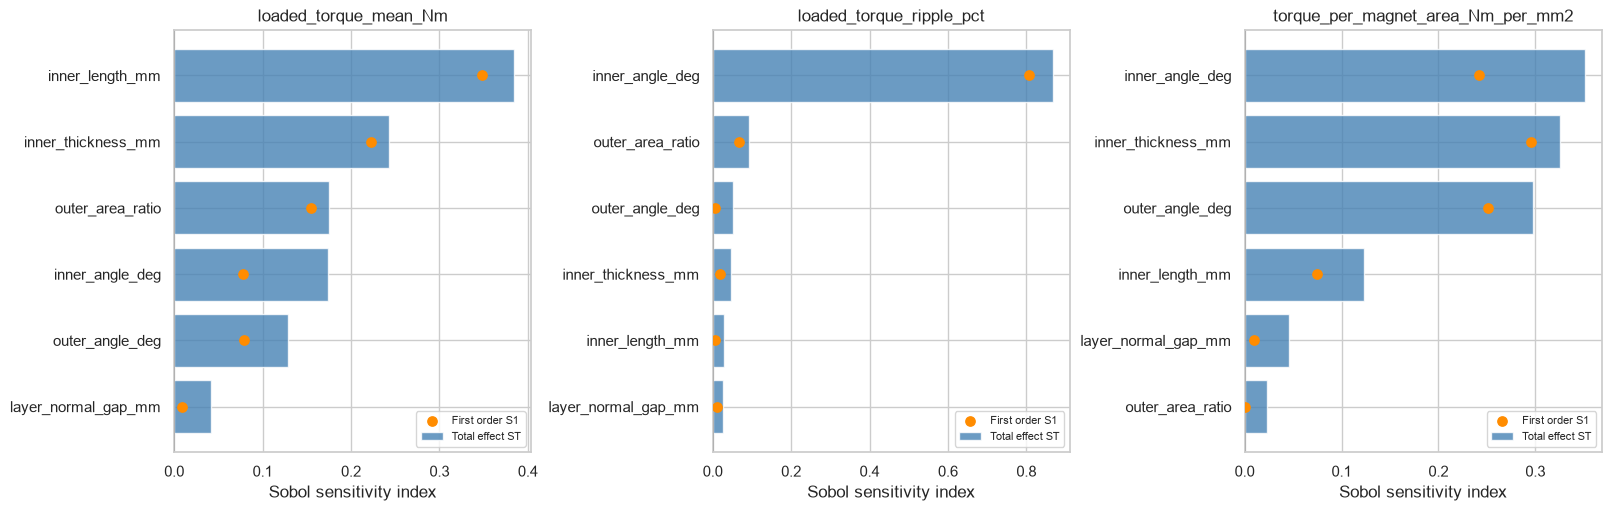

In [10]:
n_sensitivity = 8192
unit_ab = qmc.Sobol(d=2 * len(variables), scramble=True, seed=20260805).random_base2(13)
A_unit = unit_ab[:, :len(variables)]
B_unit = unit_ab[:, len(variables):]
A = lower + A_unit * (upper - lower)
B = lower + B_unit * (upper - lower)
fA, _ = dnn_predict(A)
fB, _ = dnn_predict(B)
variance = np.var(np.vstack([fA, fB]), axis=0, ddof=1)
first_order = np.zeros((len(variables), len(dnn_targets)))
total_effect = np.zeros_like(first_order)
for i in range(len(variables)):
    ABi = A.copy()
    ABi[:, i] = B[:, i]
    fABi, _ = dnn_predict(ABi)
    first_order[i] = np.mean(fB * (fABi - fA), axis=0) / variance
    total_effect[i] = np.mean((fA - fABi) ** 2, axis=0) / (2 * variance)
sobol_first = pd.DataFrame(first_order, index=variables, columns=dnn_targets)
sobol_total = pd.DataFrame(total_effect, index=variables, columns=dnn_targets)
display(pd.concat({'S1': sobol_first, 'ST': sobol_total}, axis=1).round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
for j, target in enumerate(dnn_targets):
    order = sobol_total[target].sort_values().index
    axes[j].barh(order, sobol_total.loc[order, target], color='steelblue', alpha=0.8, label='Total effect ST')
    axes[j].scatter(sobol_first.loc[order, target], order, color='darkorange', s=45, label='First order S1', zorder=3)
    axes[j].set(title=target, xlabel='Sobol sensitivity index')
    axes[j].axvline(0, color='black', linewidth=0.7)
    axes[j].legend(fontsize=8);

## 6. DNN 후보 예측 및 3목적 진단용 Pareto

DNN 교차검증 성능이 기준 미달이므로 아래 결과는 코드 검증과 경향 확인용이다. 후보를 FEMM 재검증 대상으로 자동 채택하지 않는다.

DNN candidates: 4,096; predicted 3-objective Pareto: 90


,inner_angle_deg,outer_angle_deg,outer_area_ratio,inner_thickness_mm,inner_length_mm,layer_normal_gap_mm,angle_difference_deg,pred_loaded_torque_mean_Nm,pred_loaded_torque_ripple_pct,pred_torque_per_magnet_area_Nm_per_mm2,std_loaded_torque_mean_Nm,std_loaded_torque_ripple_pct,std_torque_per_magnet_area_Nm_per_mm2
808,89.5408,89.7411,0.5033,2.4314,15.8285,0.6708,0.2004,32.7354,3.4330,0.0699,0.7865,0.8908,0.0019
2824,87.9638,85.1095,0.5168,2.3546,16.3592,1.2165,-2.8543,37.3235,3.9813,0.0787,1.2778,1.2239,0.0028
2504,87.3881,77.1620,0.5925,2.2668,16.7427,0.5174,-10.2261,38.1293,4.2886,0.0780,1.3935,1.2673,0.0027
1224,87.5438,83.5501,0.5072,1.9573,16.5651,0.8930,-3.9937,33.6312,4.4105,0.0834,1.5850,1.4240,0.0035
2728,89.7147,79.4387,0.6187,2.1317,16.3006,0.6380,-10.2760,35.9184,4.5344,0.0804,1.2369,1.0645,0.0027
2152,88.7744,87.6643,0.5445,2.2469,16.7912,1.1518,-1.1101,39.7276,4.8204,0.0843,1.5222,1.4506,0.0035
1960,89.8582,81.0975,0.5534,2.5662,16.4063,1.0062,-8.7607,40.0421,5.1715,0.0760,1.9103,1.8942,0.0033
168,89.6097,76.1872,0.5286,1.8145,16.6038,0.7985,-13.4225,33.6080,5.4499,0.0871,1.8126,1.1729,0.0038
3344,83.2293,87.2328,0.5038,2.7066,16.5972,1.3766,4.0036,41.8528,5.4751,0.0775,1.3912,1.5811,0.0027
2556,76.9531,82.3916,0.5187,2.0423,16.7165,0.8556,5.4384,37.2128,5.6920,0.0870,1.1928,1.6216,0.0028


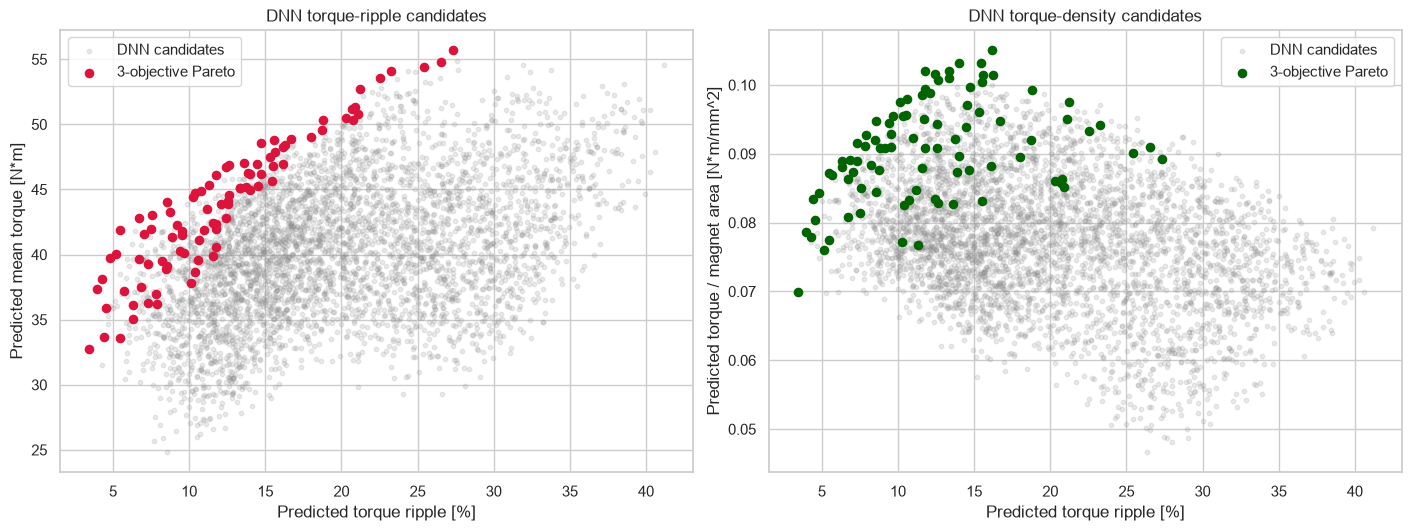

In [11]:
candidate_unit = qmc.Sobol(d=len(variables), scramble=True, seed=20260806).random_base2(12)
candidate_x = lower + candidate_unit * (upper - lower)
candidate_mean, candidate_std = dnn_predict(candidate_x)
candidate_df = pd.DataFrame(candidate_x, columns=variables)
for j, target in enumerate(dnn_targets):
    candidate_df[f'pred_{target}'] = candidate_mean[:, j]
    candidate_df[f'std_{target}'] = candidate_std[:, j]
candidate_df['angle_difference_deg'] = candidate_df['outer_angle_deg'] - candidate_df['inner_angle_deg']

torque_pred = candidate_df['pred_loaded_torque_mean_Nm'].to_numpy()
ripple_pred = candidate_df['pred_loaded_torque_ripple_pct'].to_numpy()
density_pred = candidate_df['pred_torque_per_magnet_area_Nm_per_mm2'].to_numpy()
is_dnn_pareto = np.ones(len(candidate_df), dtype=bool)
for i in range(len(candidate_df)):
    if not is_dnn_pareto[i]:
        continue
    dominates_i = (
        (torque_pred >= torque_pred[i])
        & (density_pred >= density_pred[i])
        & (ripple_pred <= ripple_pred[i])
        & (
            (torque_pred > torque_pred[i])
            | (density_pred > density_pred[i])
            | (ripple_pred < ripple_pred[i])
        )
    )
    if dominates_i.any():
        is_dnn_pareto[i] = False
candidate_df['dnn_pareto_3objective'] = is_dnn_pareto
dnn_pareto = candidate_df.loc[is_dnn_pareto].copy()
print(f'DNN candidates: {len(candidate_df):,}; predicted 3-objective Pareto: {len(dnn_pareto):,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), constrained_layout=True)
axes[0].scatter(ripple_pred, torque_pred, s=10, alpha=0.18, color='0.55', label='DNN candidates')
axes[0].scatter(dnn_pareto['pred_loaded_torque_ripple_pct'], dnn_pareto['pred_loaded_torque_mean_Nm'], s=35, color='crimson', label='3-objective Pareto')
axes[0].set(xlabel='Predicted torque ripple [%]', ylabel='Predicted mean torque [N*m]', title='DNN torque-ripple candidates')
axes[0].legend()
axes[1].scatter(ripple_pred, density_pred, s=10, alpha=0.18, color='0.55', label='DNN candidates')
axes[1].scatter(dnn_pareto['pred_loaded_torque_ripple_pct'], dnn_pareto['pred_torque_per_magnet_area_Nm_per_mm2'], s=35, color='darkgreen', label='3-objective Pareto')
axes[1].set(xlabel='Predicted torque ripple [%]', ylabel='Predicted torque / magnet area [N*m/mm^2]', title='DNN torque-density candidates')
axes[1].legend();

pareto_display_cols = variables + [
    'angle_difference_deg',
    'pred_loaded_torque_mean_Nm',
    'pred_loaded_torque_ripple_pct',
    'pred_torque_per_magnet_area_Nm_per_mm2',
    'std_loaded_torque_mean_Nm',
    'std_loaded_torque_ripple_pct',
    'std_torque_per_magnet_area_Nm_per_mm2',
]
display(
    dnn_pareto.sort_values(
        ['pred_loaded_torque_ripple_pct', 'pred_torque_per_magnet_area_Nm_per_mm2'],
        ascending=[True, False],
    )[pareto_display_cols].head(30).round(5)
)

## 7. DOE 관측점 예비 Pareto

아래 Pareto는 64개 FEMM 관측점만 사용한 예비 결과다. 최종 Pareto는 검증된 DNN으로 대규모 후보를 예측한 뒤 별도 섹션에서 계산한다.

Pareto candidates


,run,candidate,inner_angle_deg,outer_angle_deg,outer_area_ratio,inner_thickness_mm,inner_length_mm,layer_normal_gap_mm,loaded_torque_mean_Nm,loaded_torque_ripple_pct,loaded_torque_pkpk_Nm,balanced_score
39,40,42,78.3712,85.5641,0.5537,2.7119,16.5454,0.9333,42.3680,6.3417,2.6868,3.1568
24,25,26,80.9367,82.8469,0.6889,2.5285,16.1373,1.0379,42.6968,9.7857,4.1782,2.7550
9,10,10,80.5303,72.9173,0.7361,2.0139,16.3517,1.6133,43.2350,13.2062,5.7097,2.3929
58,59,63,87.9453,62.9197,0.5711,2.0166,16.0933,1.9664,43.8805,13.4161,5.8870,2.4777
48,49,52,63.8964,79.3176,0.6961,2.1081,16.7114,0.6156,45.7675,17.4699,7.9955,2.2668
19,20,21,58.5027,59.2518,0.5689,2.5962,16.6678,1.5441,45.9938,19.7895,9.1019,1.9970
57,58,62,65.9490,87.8461,0.7172,2.2583,16.2487,1.3937,46.1664,20.5624,9.4929,1.9241
14,15,15,83.8657,65.4758,0.7066,2.2082,16.5553,1.8622,51.7986,20.8364,10.7930,2.8713
60,61,66,88.0594,76.4802,0.7669,2.5591,16.7884,1.2994,56.4903,28.5625,16.1351,2.6606


Balanced-score top 10 (equal emphasis on standardized torque gain and ripple reduction)


,run,candidate,inner_angle_deg,outer_angle_deg,outer_area_ratio,inner_thickness_mm,inner_length_mm,layer_normal_gap_mm,loaded_torque_mean_Nm,loaded_torque_ripple_pct,loaded_torque_pkpk_Nm,balanced_score
39,40,42,78.3712,85.5641,0.5537,2.7119,16.5454,0.9333,42.3680,6.3417,2.6868,3.1568
14,15,15,83.8657,65.4758,0.7066,2.2082,16.5553,1.8622,51.7986,20.8364,10.7930,2.8713
24,25,26,80.9367,82.8469,0.6889,2.5285,16.1373,1.0379,42.6968,9.7857,4.1782,2.7550
60,61,66,88.0594,76.4802,0.7669,2.5591,16.7884,1.2994,56.4903,28.5625,16.1351,2.6606
58,59,63,87.9453,62.9197,0.5711,2.0166,16.0933,1.9664,43.8805,13.4161,5.8870,2.4777
18,19,20,62.2042,81.6543,0.5797,2.6812,16.4727,1.8576,49.9697,21.6114,10.7991,2.4485
9,10,10,80.5303,72.9173,0.7361,2.0139,16.3517,1.6133,43.2350,13.2062,5.7097,2.3929
48,49,52,63.8964,79.3176,0.6961,2.1081,16.7114,0.6156,45.7675,17.4699,7.9955,2.2668
28,29,30,67.9647,70.4691,0.6099,1.9680,16.6480,1.1360,41.6771,12.1484,5.0631,2.2619
13,14,14,68.3621,80.5585,0.5628,2.4495,15.8583,1.3130,43.4980,15.7676,6.8586,2.0973


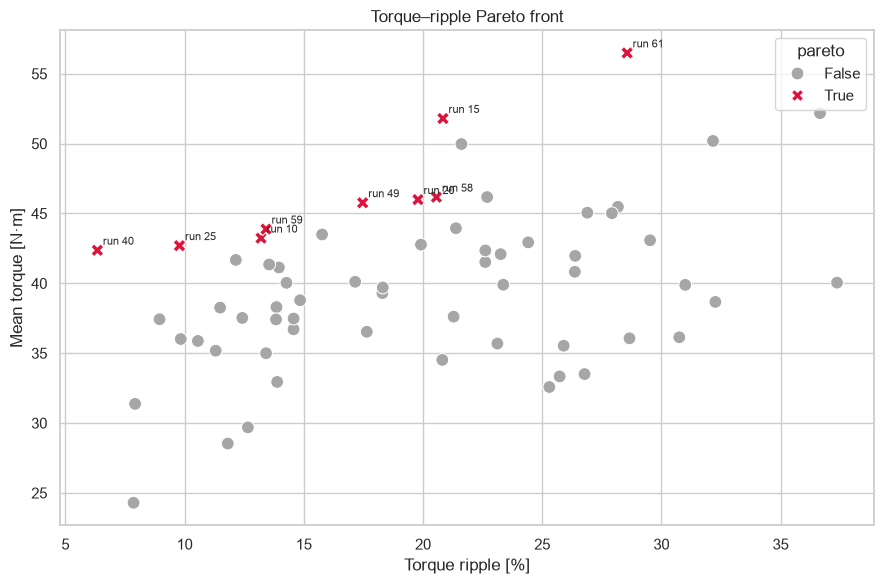

In [12]:
torque = valid['loaded_torque_mean_Nm'].to_numpy()
ripple = valid['loaded_torque_ripple_pct'].to_numpy()
is_pareto = np.ones(len(valid), dtype=bool)
for i in range(len(valid)):
    dominates_i = (torque >= torque[i]) & (ripple <= ripple[i]) & ((torque > torque[i]) | (ripple < ripple[i]))
    is_pareto[i] = not dominates_i.any()
valid['pareto'] = is_pareto

torque_norm = (valid['loaded_torque_mean_Nm'] - valid['loaded_torque_mean_Nm'].min()) / valid['loaded_torque_mean_Nm'].std(ddof=0)
ripple_norm = (valid['loaded_torque_ripple_pct'] - valid['loaded_torque_ripple_pct'].min()) / valid['loaded_torque_ripple_pct'].std(ddof=0)
valid['balanced_score'] = torque_norm - ripple_norm

plt.figure(figsize=(9, 6))
sns.scatterplot(data=valid, x='loaded_torque_ripple_pct', y='loaded_torque_mean_Nm', hue='pareto', style='pareto', s=85, palette={False:'0.65', True:'crimson'})
for _, row in valid.loc[valid['pareto']].iterrows():
    plt.annotate(f"run {int(row['run']):02d}", (row['loaded_torque_ripple_pct'], row['loaded_torque_mean_Nm']), xytext=(4, 4), textcoords='offset points', fontsize=8)
plt.xlabel('Torque ripple [%]'); plt.ylabel('Mean torque [N·m]'); plt.title('Torque–ripple Pareto front')
plt.tight_layout();

result_cols = ['run', 'candidate'] + variables + ['loaded_torque_mean_Nm', 'loaded_torque_ripple_pct', 'loaded_torque_pkpk_Nm', 'balanced_score']
print('Pareto candidates')
display(valid.loc[valid['pareto'], result_cols].sort_values('loaded_torque_ripple_pct'))
print('Balanced-score top 10 (equal emphasis on standardized torque gain and ripple reduction)')
display(valid.nlargest(10, 'balanced_score')[result_cols])

## 부록 A. 기존 상관관계 및 변수 산점도

이 섹션은 초기 탐색 결과를 보존한 부록이다. 본문 상관관계 분석은 위의 3절을 기준으로 한다.

,loaded_torque_mean_Nm,loaded_torque_ripple_pct
inner_length_mm,0.6201,-0.0387
inner_thickness_mm,0.4364,0.2194
outer_area_ratio,0.3977,0.2167
outer_angle_deg,0.3242,0.0722
layer_normal_gap_mm,0.0960,-0.0285
inner_angle_deg,-0.0914,-0.8179


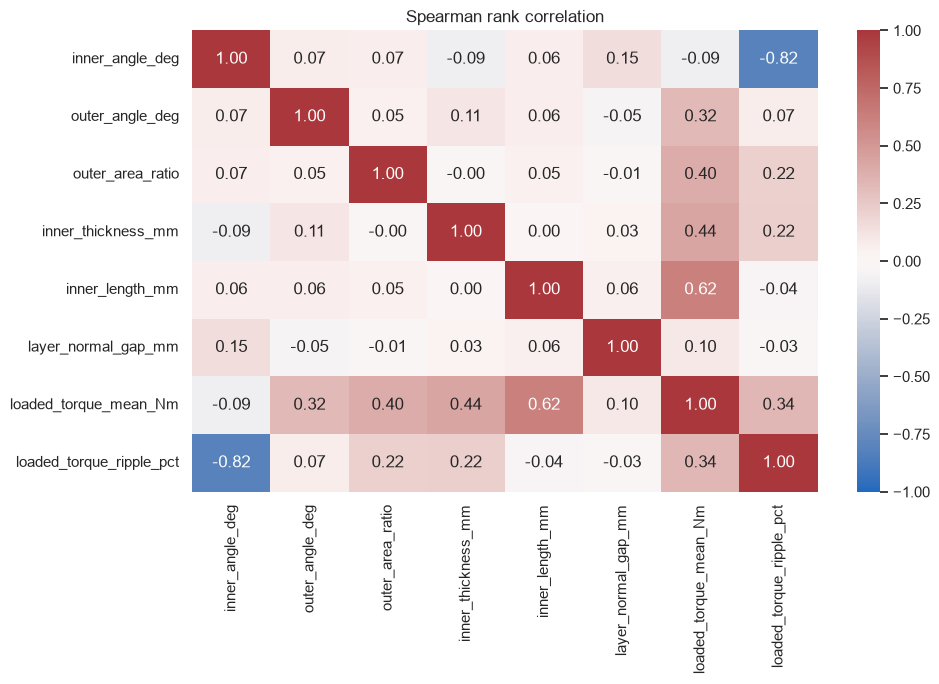

In [13]:
corr = valid[variables + responses[:2]].corr(method='spearman')
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, vmin=-1, vmax=1)
plt.title('Spearman rank correlation')
plt.tight_layout();
display(corr.loc[variables, responses[:2]].sort_values('loaded_torque_mean_Nm', ascending=False))

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_6712\253337859.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout();


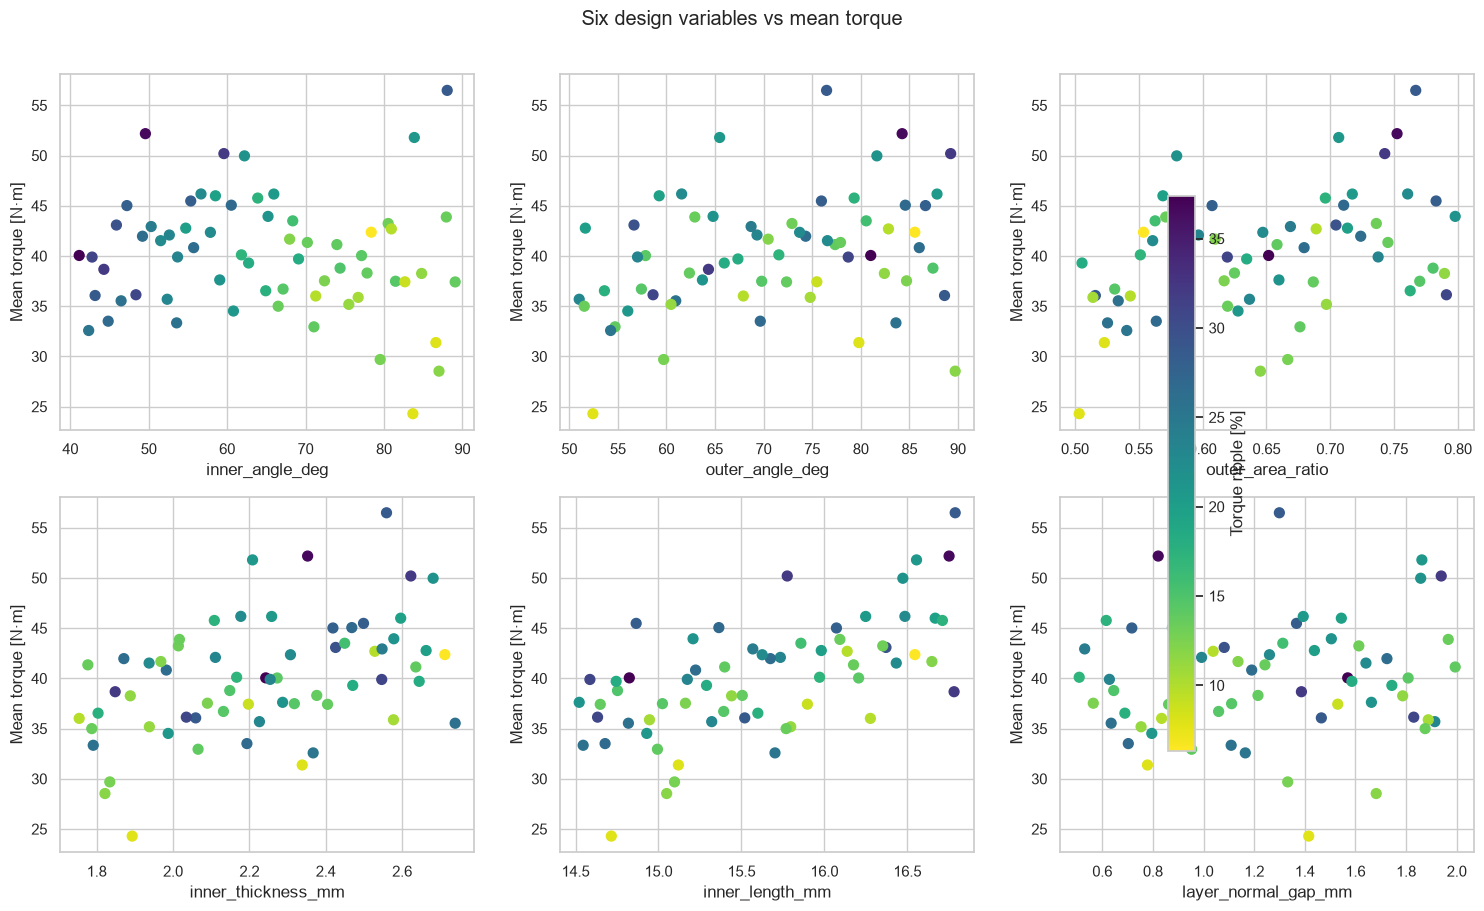

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for x, ax in zip(variables, axes.flat):
    points = ax.scatter(valid[x], valid['loaded_torque_mean_Nm'], c=valid['loaded_torque_ripple_pct'], cmap='viridis_r', s=50)
    ax.set(xlabel=x, ylabel='Mean torque [N·m]')
fig.colorbar(points, ax=axes, label='Torque ripple [%]', shrink=0.8)
fig.suptitle('Six design variables vs mean torque', y=1.01)
plt.tight_layout();

## 6. 내측–외측 각도 대각선 비교 (`y=x`)

`outer_angle_deg = inner_angle_deg`를 기준으로 외측 각도가 더 큰 영역과 내측 각도가 더 큰 영역을 나눈다. 첫 번째 셀은 평균토크, 두 번째 셀은 자석 사용량 대비 토크밀도를 토크리플과 함께 비교한다.

### 평균토크 기준

,n,mean_torque_Nm,median_torque_Nm,mean_ripple_pct,median_ripple_pct,mean_pkpk_Nm
angle_region,,,,,,
outer < inner,25,38.1835,37.4160,15.0475,13.8537,5.9631
outer > inner,39,41.2067,41.5251,22.6561,23.2572,9.3849


,angle_difference_deg,loaded_torque_mean_Nm,loaded_torque_ripple_pct,loaded_torque_pkpk_Nm
angle_difference_deg,1.0000,0.2874,0.7128,0.6546


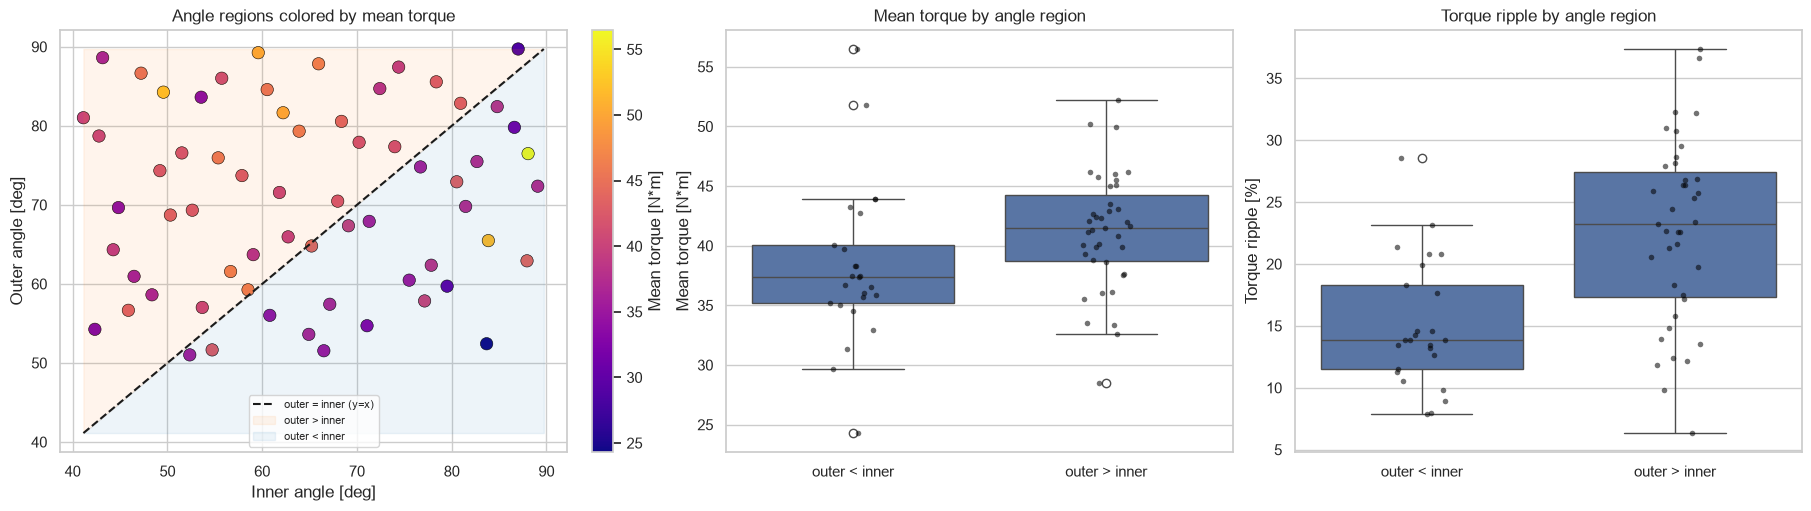

In [15]:
angle_mean_view = valid.copy()
angle_mean_view['angle_difference_deg'] = angle_mean_view['outer_angle_deg'] - angle_mean_view['inner_angle_deg']
angle_mean_view['angle_region'] = np.where(
    angle_mean_view['angle_difference_deg'] > 0, 'outer > inner',
    np.where(angle_mean_view['angle_difference_deg'] < 0, 'outer < inner', 'outer = inner')
)

mean_torque_region_summary = (
    angle_mean_view.groupby('angle_region')
    .agg(
        n=('run', 'size'),
        mean_torque_Nm=('loaded_torque_mean_Nm', 'mean'),
        median_torque_Nm=('loaded_torque_mean_Nm', 'median'),
        mean_ripple_pct=('loaded_torque_ripple_pct', 'mean'),
        median_ripple_pct=('loaded_torque_ripple_pct', 'median'),
        mean_pkpk_Nm=('loaded_torque_pkpk_Nm', 'mean'),
    )
    .round(4)
)
display(mean_torque_region_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
scatter = axes[0].scatter(
    angle_mean_view['inner_angle_deg'], angle_mean_view['outer_angle_deg'],
    c=angle_mean_view['loaded_torque_mean_Nm'], s=80, cmap='plasma',
    edgecolor='black', linewidth=0.4
)
lo = min(angle_mean_view['inner_angle_deg'].min(), angle_mean_view['outer_angle_deg'].min())
hi = max(angle_mean_view['inner_angle_deg'].max(), angle_mean_view['outer_angle_deg'].max())
axes[0].plot([lo, hi], [lo, hi], 'k--', linewidth=1.5, label='outer = inner (y=x)')
axes[0].fill_between([lo, hi], [lo, hi], hi, color='tab:orange', alpha=0.08, label='outer > inner')
axes[0].fill_between([lo, hi], lo, [lo, hi], color='tab:blue', alpha=0.08, label='outer < inner')
axes[0].set(xlabel='Inner angle [deg]', ylabel='Outer angle [deg]', title='Angle regions colored by mean torque')
axes[0].legend(fontsize=8)
fig.colorbar(scatter, ax=axes[0], label='Mean torque [N*m]')

sns.boxplot(data=angle_mean_view, x='angle_region', y='loaded_torque_mean_Nm', ax=axes[1], order=['outer < inner', 'outer > inner'])
sns.stripplot(data=angle_mean_view, x='angle_region', y='loaded_torque_mean_Nm', ax=axes[1], order=['outer < inner', 'outer > inner'], color='black', alpha=0.55, size=4)
axes[1].set(xlabel='', ylabel='Mean torque [N*m]', title='Mean torque by angle region')

sns.boxplot(data=angle_mean_view, x='angle_region', y='loaded_torque_ripple_pct', ax=axes[2], order=['outer < inner', 'outer > inner'])
sns.stripplot(data=angle_mean_view, x='angle_region', y='loaded_torque_ripple_pct', ax=axes[2], order=['outer < inner', 'outer > inner'], color='black', alpha=0.55, size=4)
axes[2].set(xlabel='', ylabel='Torque ripple [%]', title='Torque ripple by angle region');

display(
    angle_mean_view[['angle_difference_deg', 'loaded_torque_mean_Nm', 'loaded_torque_ripple_pct', 'loaded_torque_pkpk_Nm']]
    .corr().loc[['angle_difference_deg']].round(4)
)

### 자석 사용량 대비 토크밀도 기준

,n,mean_torque_density,median_torque_density,mean_ripple_pct,median_ripple_pct,mean_pkpk_Nm
angle_region,,,,,,
outer < inner,25,0.0793,0.0772,15.0475,13.8537,5.9631
outer > inner,39,0.0773,0.0780,22.6561,23.2572,9.3849


,angle_difference_deg,torque_per_magnet_area_Nm_per_mm2,loaded_torque_ripple_pct,loaded_torque_pkpk_Nm
angle_difference_deg,1.0000,-0.1193,0.7128,0.6546


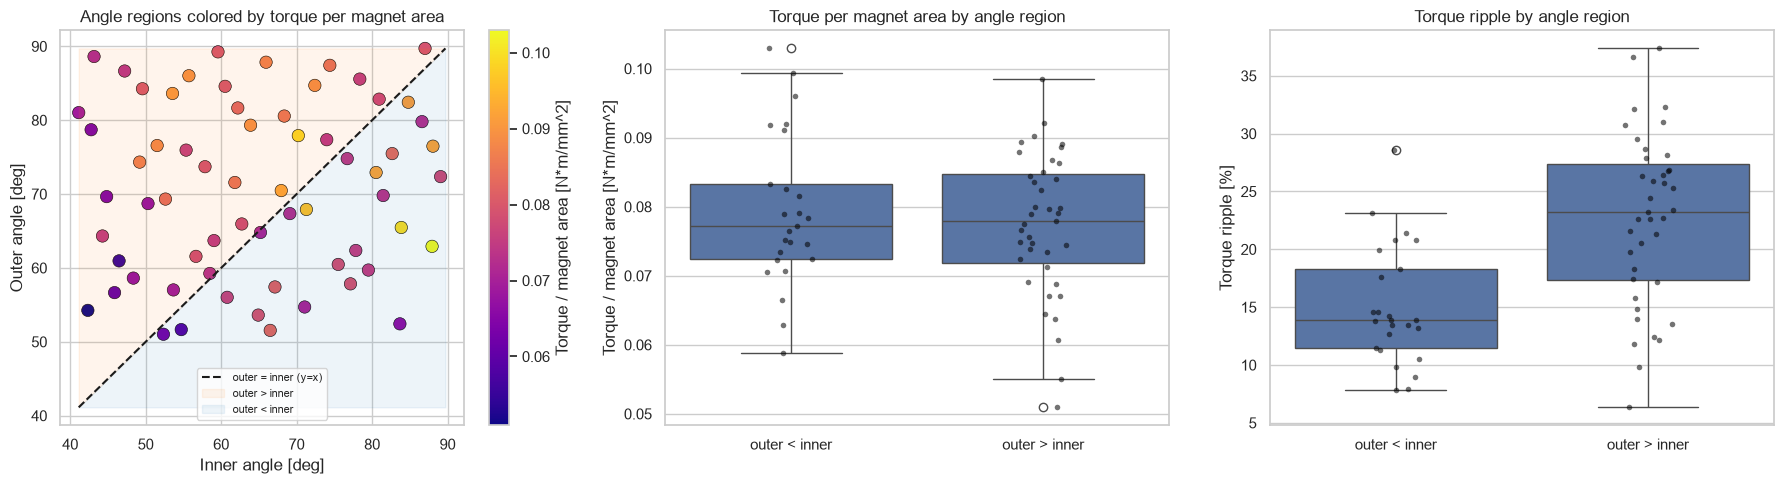

In [16]:
angle_view = efficiency_view.copy()
angle_view['angle_difference_deg'] = angle_view['outer_angle_deg'] - angle_view['inner_angle_deg']
angle_view['angle_region'] = np.where(
    angle_view['angle_difference_deg'] > 0, 'outer > inner',
    np.where(angle_view['angle_difference_deg'] < 0, 'outer < inner', 'outer = inner')
)

region_summary = (
    angle_view.groupby('angle_region')
    .agg(
        n=('run', 'size'),
        mean_torque_density=('torque_per_magnet_area_Nm_per_mm2', 'mean'),
        median_torque_density=('torque_per_magnet_area_Nm_per_mm2', 'median'),
        mean_ripple_pct=('loaded_torque_ripple_pct', 'mean'),
        median_ripple_pct=('loaded_torque_ripple_pct', 'median'),
        mean_pkpk_Nm=('loaded_torque_pkpk_Nm', 'mean'),
    )
    .round(4)
)
display(region_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
scatter = axes[0].scatter(
    angle_view['inner_angle_deg'], angle_view['outer_angle_deg'],
    c=angle_view['torque_per_magnet_area_Nm_per_mm2'], s=80, cmap='plasma', edgecolor='black', linewidth=0.4
)
lo = min(angle_view['inner_angle_deg'].min(), angle_view['outer_angle_deg'].min())
hi = max(angle_view['inner_angle_deg'].max(), angle_view['outer_angle_deg'].max())
axes[0].plot([lo, hi], [lo, hi], 'k--', linewidth=1.5, label='outer = inner (y=x)')
axes[0].fill_between([lo, hi], [lo, hi], hi, color='tab:orange', alpha=0.08, label='outer > inner')
axes[0].fill_between([lo, hi], lo, [lo, hi], color='tab:blue', alpha=0.08, label='outer < inner')
axes[0].set(xlabel='Inner angle [deg]', ylabel='Outer angle [deg]', title='Angle regions colored by torque per magnet area')
axes[0].legend(fontsize=8)
fig.colorbar(scatter, ax=axes[0], label='Torque / magnet area [N*m/mm^2]')

sns.boxplot(data=angle_view, x='angle_region', y='torque_per_magnet_area_Nm_per_mm2', ax=axes[1], order=['outer < inner', 'outer > inner'])
sns.stripplot(data=angle_view, x='angle_region', y='torque_per_magnet_area_Nm_per_mm2', ax=axes[1], order=['outer < inner', 'outer > inner'], color='black', alpha=0.55, size=4)
axes[1].set(xlabel='', ylabel='Torque / magnet area [N*m/mm^2]', title='Torque per magnet area by angle region')

sns.boxplot(data=angle_view, x='angle_region', y='loaded_torque_ripple_pct', ax=axes[2], order=['outer < inner', 'outer > inner'])
sns.stripplot(data=angle_view, x='angle_region', y='loaded_torque_ripple_pct', ax=axes[2], order=['outer < inner', 'outer > inner'], color='black', alpha=0.55, size=4)
axes[2].set(xlabel='', ylabel='Torque ripple [%]', title='Torque ripple by angle region')
plt.tight_layout();

display(
    angle_view[['angle_difference_deg', 'torque_per_magnet_area_Nm_per_mm2', 'loaded_torque_ripple_pct', 'loaded_torque_pkpk_Nm']]
    .corr().loc[['angle_difference_deg']].round(4)
)

### 해석

- `outer > inner`와 `outer < inner` 영역의 자석 사용량 대비 평균토크를 직접 비교한다.
- 토크밀도가 높더라도 토크리플이 함께 커지는지 세 번째 그래프로 확인한다.
- 이 비교는 나머지 네 설계변수가 함께 변한 64점의 단순 그룹 비교이므로 인과효과로 해석하면 안 된다. 후속 GP/Kriging 분석에서는 다른 변수들을 통제한 각도차 효과를 확인해야 한다.

## 해석 시 주의사항

- 64점 Sobol 표본에 대한 탐색적 비교이며 전역 최적해를 보장하지 않는다.
- `balanced_score`는 표준화된 평균토크와 리플에 동일 가중치를 준 참고 지표다. 실제 설계 요구에 맞춰 가중치 또는 제약조건을 조정해야 한다.
- 최종 후보는 세부 메시/각도 스텝으로 재검증하고 무부하 특성 및 구조 제약도 함께 확인하는 것이 좋다.

## 8. Independent-angle best/worst 형상과 1차 MEC $L_d,L_q$ 근사

64개 정상 FEMM 관측점에서 **평균토크 최대점과 최소점**을 고르고, 해석에 사용한
독립 내·외측 각도와 면적비를 그대로 적용해 실제 자석 배치를 다시 그린다.

이후 실제 치수를 자기등가회로(MEC)로 축약해
$L_d/N_{eff}^2=1/\mathcal R_d$,
$L_q/N_{eff}^2=1/\mathcal R_q$를 계산한다. 출력의 `µH/turn²`는 권선 영향을
제거한 형상 permeance 지표이며, `N_EFF`에 축 기준 유효 직렬 턴수를 넣으면 mH로 환산된다.

> 선형·비포화 1차 근사이므로 슬롯 누설, 프린징, 브리지 포화와 d–q 교차포화를 생략한다.
> 형상 간 방향성과 saliency 비교용이며 실제 $L_d,L_q$ 입증값은 아니다.

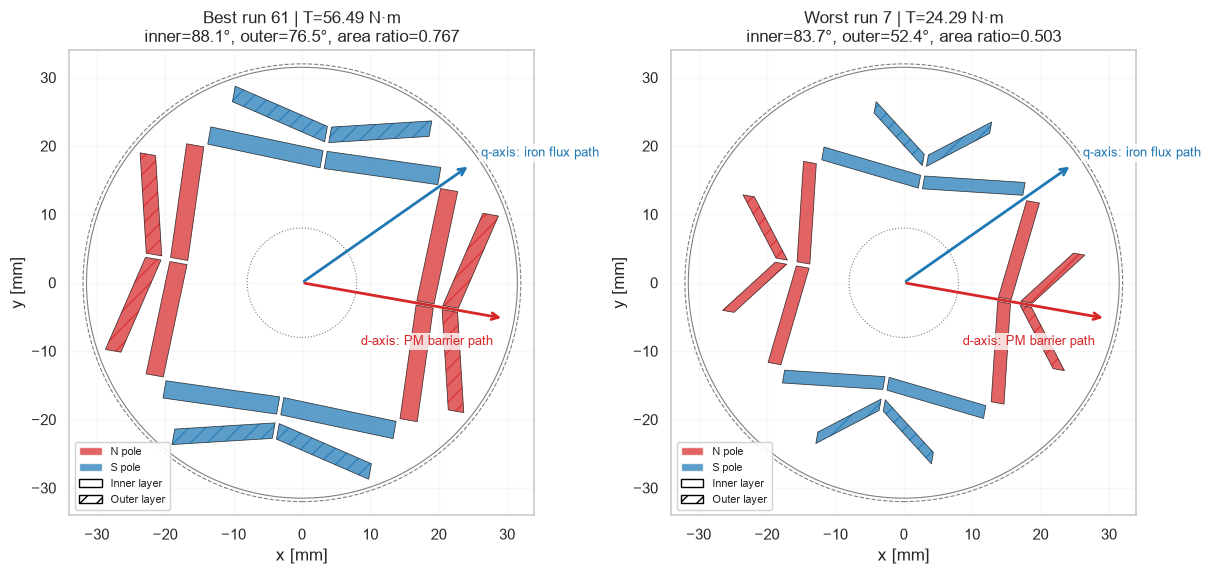

,best,worst
inner_angle_deg,88.0594,83.6827
outer_angle_deg,76.4802,52.4300
outer_area_ratio,0.7669,0.5033
inner_thickness_mm,2.5591,1.8929
inner_length_mm,16.7884,14.7156
layer_normal_gap_mm,1.2994,1.4153
loaded_torque_mean_Nm,56.4903,24.2943
loaded_torque_ripple_pct,28.5625,7.8585
loaded_torque_pkpk_Nm,16.1351,1.9092


In [17]:
import sys
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import generate_split_angle_double_layer_preview as independent_geom

best_mec_row = valid.loc[valid['loaded_torque_mean_Nm'].idxmax()].copy()
worst_mec_row = valid.loc[valid['loaded_torque_mean_Nm'].idxmin()].copy()

def independent_magnets(row):
    g = independent_geom
    g.INNER_THICKNESS_MM = float(row.inner_thickness_mm)
    g.OUTER_THICKNESS_MM = float(row.outer_thickness_mm)
    g.INNER_LENGTH_MM = float(row.inner_length_mm)
    g.OUTER_LENGTH_MM = float(row.outer_length_mm)
    g.INNER_ANGLE_DEG = float(row.inner_angle_deg)
    g.OUTER_ANGLE_DEG = float(row.outer_angle_deg)
    g.OUTER_FLIPPED = False
    g.LAYER_GAP_MM = float(row.layer_normal_gap_mm)
    return g.build_magnets(
        float(row.inner_center_radius_mm), float(row.outer_center_radius_mm),
        float(row.inner_center_offset_deg), float(row.outer_center_offset_deg),
    )

def draw_independent_case(ax, row, label):
    for item in independent_magnets(row):
        pts = np.asarray(item['points'])
        pts = np.vstack([pts, pts[0]])
        # Four-pole rotor: adjacent pole groups alternate N/S colors.
        color = '#d62728' if int(item['pole']) % 2 == 0 else '#1f77b4'
        hatch = None if item['layer'] == 'inner' else '//'
        ax.fill(pts[:, 0], pts[:, 1], color=color, alpha=.72,
                hatch=hatch, edgecolor='black', linewidth=.55)
    for radius, style in [(8, ':'), (31.5, '-'), (32, '--')]:
        ax.add_patch(plt.Circle((0, 0), radius, fill=False, color='gray', ls=style, lw=.8))
    ax.set_aspect('equal'); ax.set_xlim(-34, 34); ax.set_ylim(-34, 34)
    ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]'); ax.grid(alpha=.15)
    ax.set_title(
        f"{label} run {int(row.run)} | T={row.loaded_torque_mean_Nm:.2f} N·m\n"
        f"inner={row.inner_angle_deg:.1f}°, outer={row.outer_angle_deg:.1f}°, "
        f"area ratio={row.outer_area_ratio:.3f}"
    )
    d_ang = np.deg2rad(-10)
    pole_pairs = 2
    q_ang = d_ang + np.pi / (2 * pole_pairs)  # 90 electrical deg = 45 mechanical deg
    d_end = (30*np.cos(d_ang), 30*np.sin(d_ang))
    q_end = (30*np.cos(q_ang), 30*np.sin(q_ang))
    # Keep both vectors rooted at the rotor center; place labels separately.
    ax.annotate('', xy=d_end, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', lw=2, color='#d62728'))
    ax.annotate('', xy=q_end, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', lw=2, color='#1f77b4'))
    ax.annotate('d-axis: PM barrier path', xy=d_end, xytext=(-8, -12),
                textcoords='offset points', ha='right', va='top',
                fontsize=9, color='#d62728',
                bbox=dict(facecolor='white', edgecolor='none', alpha=.78, pad=1.5))
    ax.annotate('q-axis: iron flux path', xy=q_end, xytext=(8, 4),
                textcoords='offset points', ha='left', va='bottom',
                fontsize=9, color='#1f77b4',
                bbox=dict(facecolor='white', edgecolor='none', alpha=.78, pad=1.5))
    pole_legend = [
        plt.matplotlib.patches.Patch(facecolor='#d62728', alpha=.72, label='N pole'),
        plt.matplotlib.patches.Patch(facecolor='#1f77b4', alpha=.72, label='S pole'),
        plt.matplotlib.patches.Patch(facecolor='white', edgecolor='black', label='Inner layer'),
        plt.matplotlib.patches.Patch(facecolor='white', edgecolor='black', hatch='//', label='Outer layer'),
    ]
    ax.legend(handles=pole_legend, loc='lower left', fontsize=8, framealpha=.9)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.8), constrained_layout=True)
draw_independent_case(axes[0], best_mec_row, 'Best')
draw_independent_case(axes[1], worst_mec_row, 'Worst')
plt.show()

display(pd.DataFrame({
    'best': best_mec_row[variables + responses].copy(),
    'worst': worst_mec_row[variables + responses].copy(),
}).round(5))

In [18]:
MU0 = 4e-7 * np.pi
MU_R_PM = 1.05
MU_R_FE_LINEAR = 2000.0
AIRGAP_MM = 0.5
STACK_MM = float(getattr(independent_geom.base, 'DEPTH', 50.0))
POLE_ARC_FACTOR = 0.72
N_EFF = 1.0

def independent_mec_estimate(row):
    r_gap_mm = 31.75
    pole_pitch_mm = 2 * np.pi * r_gap_mm / 4
    A_gap = POLE_ARC_FACTOR * pole_pitch_mm * STACK_MM * 1e-6
    R_gap_pair = 2 * AIRGAP_MM * 1e-3 / (MU0 * A_gap)

    # 좌우 wing은 병렬, 내·외층은 d축 자속에 대해 직렬인 1차 근사.
    A_inner = 2 * float(row.inner_length_mm) * STACK_MM * 1e-6
    A_outer = 2 * float(row.outer_length_mm) * STACK_MM * 1e-6
    R_pm_d = float(row.inner_thickness_mm) * 1e-3 / (MU0 * MU_R_PM * A_inner)
    R_pm_d += float(row.outer_thickness_mm) * 1e-3 / (MU0 * MU_R_PM * A_outer)

    # 두 독립 각도의 횡방향 철심 통로 투영과 실제 최소 브리지를 q축 병목 proxy로 사용.
    inner_cross = float(row.inner_length_mm) * max(abs(np.cos(np.deg2rad(row.inner_angle_deg))), .08)
    outer_cross = float(row.outer_length_mm) * max(abs(np.cos(np.deg2rad(row.outer_angle_deg))), .08)
    bridge = max(float(row.exact_outer_bridge_min_mm), .10)
    A_q = STACK_MM * max(inner_cross + outer_cross + 2 * bridge, 1.0) * 1e-6
    rotor_path_mm = .35 * 2 * (float(row.inner_length_mm) + float(row.outer_length_mm)) / 2
    R_rotor_q = rotor_path_mm * 1e-3 / (MU0 * MU_R_FE_LINEAR * A_q)

    Ld = 1 / (R_gap_pair + R_pm_d)
    Lq = 1 / (R_gap_pair + R_rotor_q)
    return pd.Series({
        'Ld_uH_per_turn2': Ld * 1e6,
        'Lq_uH_per_turn2': Lq * 1e6,
        'Lq_over_Ld': Lq / Ld,
        'saliency_uH_per_turn2': (Lq - Ld) * 1e6,
        'Ld_mH_at_Neff': Ld * N_EFF**2 * 1e3,
        'Lq_mH_at_Neff': Lq * N_EFF**2 * 1e3,
    })

independent_mec = pd.DataFrame({
    f'Best run {int(best_mec_row.run)}': independent_mec_estimate(best_mec_row),
    f'Worst run {int(worst_mec_row.run)}': independent_mec_estimate(worst_mec_row),
}).T
display(independent_mec.round(5))

print('판정: Lq/Ld와 (Lq-Ld)/N_eff²가 클수록 선형 MEC상 saliency가 큼')
print('주의: 실제 릴럭턴스 토크 입증에는 동일 운전점의 ±Id/±Iq FEMM 자속쇄교가 필요함')

,Ld_uH_per_turn2,Lq_uH_per_turn2,Lq_over_Ld,saliency_uH_per_turn2,Ld_mH_at_Neff,Lq_mH_at_Neff
Best run 61,1.0894,6.5847,6.0442,5.4953,0.0011,0.0066
Worst run 7,1.2536,6.7076,5.3505,5.4540,0.0013,0.0067


판정: Lq/Ld와 (Lq-Ld)/N_eff²가 클수록 선형 MEC상 saliency가 큼
주의: 실제 릴럭턴스 토크 입증에는 동일 운전점의 ±Id/±Iq FEMM 자속쇄교가 필요함


### 해석 기준

- 평균토크 best/worst의 MEC 결과가 실제 토크 순서와 같으면 saliency 차이가 토크 차이에
  기여했을 가능성을 지지한다.
- 순서가 다르거나 차이가 작으면 PM 기본파, 포화 또는 전류각 효과가 더 지배적일 수 있다.
- 이 비교는 **인과관계 확정이 아니라 다음 FEMM d/q 해석 대상을 고르는 선별 단계**다.

## 9. Analysis idea: interaction between commutation angle and rotor geometry

### 현재 상관관계가 의미하는 것

현재 64점 데이터는 모두 고정된 commutation angle $\beta=35^\circ$에서 생성됐다.
따라서 현재 Spearman 상관계수는 형상의 절대적 중요도가 아니라 특정 운전점에서의
조건부 단조 관계다.

$$
\rho\!\left(X_j,T\mid\beta=35^\circ\right)
$$

여기서 $X_j$는 inner angle, outer angle, 자석 면적비 등 설계변수다. 그러므로 현재
inner angle의 상관계수가 작더라도, inner angle이 토크에 본질적으로 중요하지 않다고
결론 내릴 수 없다. 해당 운전점에서 효과가 약하거나 다른 변수와의 상호작용에 가려졌을
가능성이 있다.

### 연구 가설

회전자 형상은 PM 자속쇄교 $\psi_{pm}$, saliency $L_q-L_d$, 포화 상태를 변화시키므로
최대 토크 전류각(MTPA point)도 바꾼다.

$$
T=\frac{3}{2}p\left[\psi_{pm}i_q+(L_d-L_q)i_di_q\right]
$$

따라서 모든 형상에 동일한 $\beta$를 적용하면 어떤 형상은 최적 전류각 부근에서,
다른 형상은 최적점에서 멀리 떨어진 상태로 비교될 수 있다. 이 경우 고정 $\beta$ 분석은
특정 형상변수의 실제 최대토크 기여를 축소하거나 순위를 바꿀 수 있다.

### 제안 분석 1: commutation angle별 조건부 민감도

동일한 geometry population을 유지하고 전류 크기만 10 A로 고정한 채 다음과 같이
commutation angle을 스윕한다.

$$
\beta\in\{0^\circ,-5^\circ,-10^\circ,\ldots,-35^\circ\}
$$

각 $\beta$에서 다음을 계산한다.

1. 회전자 위치 스윕의 평균토크와 토크리플
2. 각 설계변수와 평균토크 사이의 Spearman 상관계수
3. 선택적으로 Random Forest permutation importance 또는 SHAP

최종 결과는 하나의 상관행렬이 아니라 다음 함수가 된다.

$$
\rho_j(\beta)=\rho\!\left(X_j,T\mid\beta\right)
$$

이를 $\beta$–correlation 곡선으로 나타내면 각 형상변수가 어느 운전점에서 강하게
작용하는지, 상관 부호가 바뀌는지, 특정 각도에서만 영향이 드러나는지 확인할 수 있다.

### 제안 분석 2: 형상별 MTPA 응답 생성

각 형상 $x$에 대해 commutation angle을 스윕하여 다음 응답을 새로 정의한다.

$$
T_{max}(x)=\max_{\beta}T(x,\beta),\qquad
\beta_{MTPA}(x)=\operatorname*{arg\,max}_{\beta}T(x,\beta)
$$

저장할 핵심 응답은 다음과 같다.

- `mtpa_mean_torque_Nm`: 형상별 최대 평균토크
- `mtpa_angle_deg`: 최대토크 commutation angle
- `mtpa_ripple_pct`: MTPA에서의 토크리플
- `torque_at_fixed_35deg`: 기존 고정 제어각 결과

이후 다음 두 관계를 별도로 분석한다.

$$
\rho(X_j,T_{max}),\qquad \rho(X_j,\beta_{MTPA})
$$

첫 번째는 형상이 최대토크 능력에 미치는 영향이고, 두 번째는 형상이 요구하는 최적 제어각에
미치는 영향이다. 이를 통해 전자기 형상 설계와 전류 제어의 결합효과를 분리해 설명할 수 있다.

### 실행 및 해석 시 주의사항

- 현재 코드에서 commutation angle의 양·음 방향이 $i_d<0$ 방향과 일치하는지 먼저 한 형상으로 확인한다.
- 모든 $\beta$에서 동일한 형상점과 동일한 회전자 위치를 사용해야 paired comparison이 된다.
- 단순 Spearman은 다른 변수와의 상호작용을 분리하지 않으므로, 충분한 데이터가 확보되면
  `Geometry × β`를 함께 입력한 GP 또는 상호작용 모델로 검증한다.
- Random Forest importance와 SHAP 역시 학습모델의 교차검증 성능이 확보된 뒤 해석한다.
- 계산량을 줄이려면 먼저 대표 형상 일부로 $\beta$ 범위와 간격을 찾고, 이후 64개 전체에 적용한다.

### 연구적 의미

현재 데이터는 **35°라는 특정 운전점에서의 형상 중요도**를 보여준다. 제안 분석은 형상변수의
중요도가 운전점에 따라 어떻게 달라지는지 밝히고, 고정 commutation angle에서 약하게 보인
V-angle 등의 변수가 각 형상의 MTPA 부근에서 지배적으로 나타나는지를 검증한다. 이는 형상
최적화와 제어 최적화를 독립적으로 다루지 않고 결합해서 평가한다는 점에 의미가 있다.

## 10. 토크 성능과 리플을 함께 고려한 복합 목적함수

현재 응답은 평균토크, 토크리플, 자석면적당 토크의 세 가지다. Pareto 분석은 이들 사이의
trade-off를 보존한다는 장점이 있지만, 실제 설계 의사결정을 위해서는 토크를 높이면서
리플을 낮추는 하나의 품질지표도 함께 검토할 수 있다.

비율형 후보는 다음과 같다.

$$
J_{ratio}=\frac{T_{mean}}{T_{pkpk}+\epsilon}
$$

단, 현재 `loaded_torque_ripple_pct`의 정의가

$$
T_{ripple,\%}=100\frac{T_{pkpk}}{T_{mean}}
$$

라면 $T_{mean}/T_{pkpk}=100/T_{ripple,\%}$이므로 두 지표는 동일한 정보를 갖는다.
또한 $T_{mean}/T_{ripple,\%}$는
$T_{mean}^2/(100T_{pkpk})$가 되어 평균토크를 이중으로 강조한다. 따라서 비율만 쓰지 않고
두 응답을 표준화한 동일가중 균형점수도 함께 사용한다.

$$
J_{balanced}=z(T_{mean})-z(T_{ripple,\%})
$$

아래 셀은 관측점에서 두 복합지표를 계산하고, 기존 DNN 예측함수로
$J_{balanced}$의 진단용 Sobol 지수를 계산한다. DNN 검증성능이 충분하지 않으므로 이
민감도는 연구가설 생성용이며 최종 결론에는 검증된 대리모델 또는 추가 FEMM 점이 필요하다.

,count,mean,std,min,25%,50%,75%,max
J_torque_over_pkpk,64.0000,6.0016,2.7038,2.6762,3.8800,5.0373,7.4000,15.7687
J_torque_over_ripple_pct,64.0000,2.3409,0.9633,1.0718,1.6136,2.2066,2.7749,6.6809
J_balanced,64.0000,-0.0000,1.1087,-2.3534,-0.6635,0.0803,0.7388,2.1882


,run,inner_angle_deg,outer_angle_deg,outer_area_ratio,inner_thickness_mm,inner_length_mm,layer_normal_gap_mm,loaded_torque_mean_Nm,loaded_torque_ripple_pct,J_torque_over_pkpk,J_balanced
39,40,78.3712,85.5641,0.5537,2.7119,16.5454,0.9334,42.3680,6.3417,15.7687,2.1882
14,15,83.8658,65.4758,0.7066,2.2082,16.5553,1.8622,51.7987,20.8364,4.7993,1.9026
24,25,80.9367,82.8469,0.6889,2.5285,16.1373,1.0379,42.6968,9.7857,10.2189,1.7864
60,61,88.0594,76.4802,0.7669,2.5591,16.7884,1.2994,56.4903,28.5625,3.5011,1.6919
58,59,87.9453,62.9197,0.5711,2.0166,16.0933,1.9664,43.8805,13.4161,7.4538,1.5091
18,19,62.2042,81.6543,0.5797,2.6812,16.4728,1.8576,49.9697,21.6114,4.6272,1.4799
9,10,80.5303,72.9173,0.7361,2.0139,16.3517,1.6133,43.2350,13.2062,7.5722,1.4243
48,49,63.8965,79.3176,0.6961,2.1081,16.7114,0.6156,45.7675,17.4699,5.7241,1.2981
28,29,67.9647,70.4691,0.6099,1.9680,16.6480,1.1360,41.6771,12.1484,8.2316,1.2932
13,14,68.3621,80.5585,0.5628,2.4495,15.8583,1.3130,43.4980,15.7676,6.3421,1.1287


,J_torque_over_pkpk,J_balanced
inner_angle_deg,0.8179,0.6505
outer_angle_deg,-0.0722,0.2086
outer_area_ratio,-0.2167,0.1297
inner_thickness_mm,-0.2194,0.2278
inner_length_mm,0.0387,0.5824
layer_normal_gap_mm,0.0285,0.1280


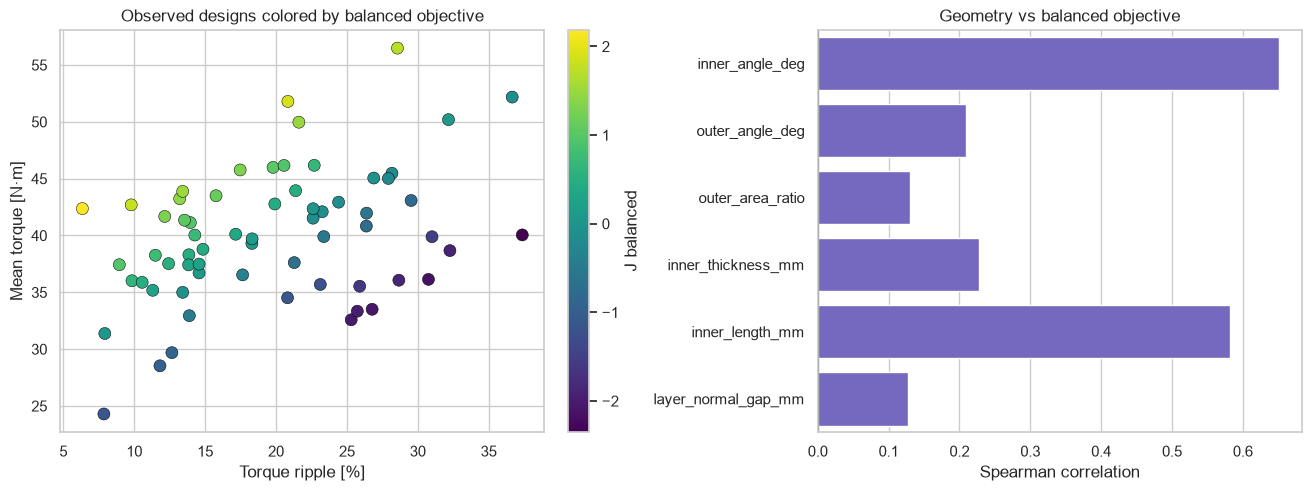

In [19]:
composite_view = efficiency_view.copy()
eps = 1e-12
composite_view['J_torque_over_pkpk'] = (
    composite_view['loaded_torque_mean_Nm'] /
    (composite_view['loaded_torque_pkpk_Nm'] + eps)
)
composite_view['J_torque_over_ripple_pct'] = (
    composite_view['loaded_torque_mean_Nm'] /
    (composite_view['loaded_torque_ripple_pct'] + eps)
)
t_mu, t_sigma = composite_view['loaded_torque_mean_Nm'].mean(), composite_view['loaded_torque_mean_Nm'].std(ddof=0)
r_mu, r_sigma = composite_view['loaded_torque_ripple_pct'].mean(), composite_view['loaded_torque_ripple_pct'].std(ddof=0)
composite_view['J_balanced'] = (
    (composite_view['loaded_torque_mean_Nm'] - t_mu) / t_sigma
    - (composite_view['loaded_torque_ripple_pct'] - r_mu) / r_sigma
)

display(composite_view[[
    'J_torque_over_pkpk', 'J_torque_over_ripple_pct', 'J_balanced'
]].describe().T.round(5))
display(composite_view.nlargest(10, 'J_balanced')[[
    'run', *variables, 'loaded_torque_mean_Nm', 'loaded_torque_ripple_pct',
    'J_torque_over_pkpk', 'J_balanced'
]].round(5))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
sc = axes[0].scatter(
    composite_view['loaded_torque_ripple_pct'], composite_view['loaded_torque_mean_Nm'],
    c=composite_view['J_balanced'], cmap='viridis', s=75, edgecolor='black', linewidth=.35
)
axes[0].set(xlabel='Torque ripple [%]', ylabel='Mean torque [N·m]',
            title='Observed designs colored by balanced objective')
fig.colorbar(sc, ax=axes[0], label='J balanced')

composite_corr = composite_view[variables + ['J_torque_over_pkpk', 'J_balanced']].corr(method='spearman')
sns.barplot(
    x=composite_corr.loc[variables, 'J_balanced'].values,
    y=composite_corr.loc[variables].index, ax=axes[1], color='slateblue'
)
axes[1].axvline(0, color='black', lw=.8)
axes[1].set(xlabel='Spearman correlation', ylabel='', title='Geometry vs balanced objective')
display(composite_corr.loc[variables, ['J_torque_over_pkpk', 'J_balanced']].round(4))

,S1,ST
inner_angle_deg,0.5624,0.5829
inner_length_mm,0.2860,0.3042
inner_thickness_mm,0.0727,0.0913
outer_angle_deg,0.0318,0.0460
outer_area_ratio,0.0073,0.0202
layer_normal_gap_mm,0.0004,0.0093


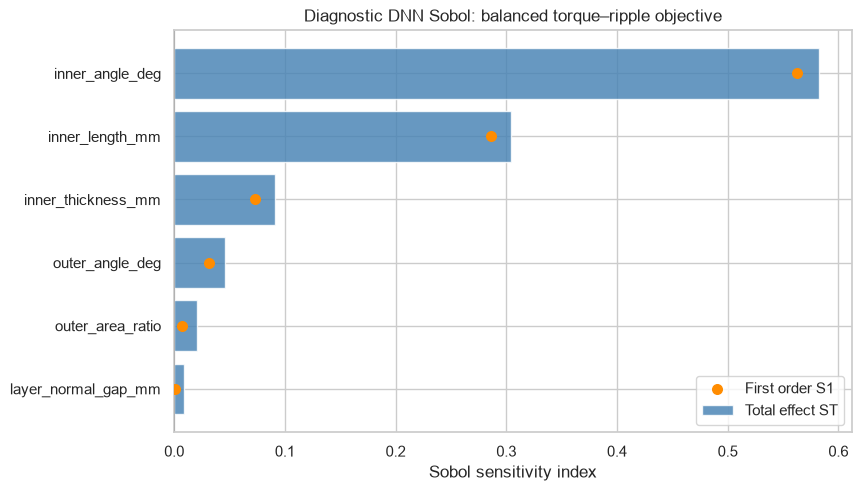

In [20]:
# Diagnostic Sobol analysis of the balanced objective using the existing DNN ensemble.
def balanced_from_dnn(x):
    prediction, _ = dnn_predict(x)
    torque_pred = prediction[:, dnn_targets.index('loaded_torque_mean_Nm')]
    ripple_pred = prediction[:, dnn_targets.index('loaded_torque_ripple_pct')]
    return (torque_pred - t_mu) / t_sigma - (ripple_pred - r_mu) / r_sigma

jA = balanced_from_dnn(A)
jB = balanced_from_dnn(B)
j_var = np.var(np.r_[jA, jB], ddof=1)
j_s1, j_st = [], []
for i in range(len(variables)):
    ABi = A.copy()
    ABi[:, i] = B[:, i]
    jABi = balanced_from_dnn(ABi)
    j_s1.append(np.mean(jB * (jABi - jA)) / j_var)
    j_st.append(np.mean((jA - jABi) ** 2) / (2 * j_var))

composite_sobol = pd.DataFrame({'S1': j_s1, 'ST': j_st}, index=variables).sort_values('ST')
display(composite_sobol.sort_values('ST', ascending=False).round(4))

fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
ax.barh(composite_sobol.index, composite_sobol['ST'], color='steelblue', alpha=.82, label='Total effect ST')
ax.scatter(composite_sobol['S1'], composite_sobol.index, color='darkorange', s=48, label='First order S1', zorder=3)
ax.axvline(0, color='black', lw=.7)
ax.set(xlabel='Sobol sensitivity index', title='Diagnostic DNN Sobol: balanced torque–ripple objective')
ax.legend()
plt.show()

## 11. Discussion에 강조할 설계 해석

현재 고정 commutation angle 데이터와 진단용 민감도 결과가 후속 검증에서도 유지된다면,
다음 세 가지를 핵심 메시지로 제시할 수 있다.

1. **평균토크:** 자석 길이와 두께처럼 PM 자속량을 결정하는 설계변수가 평균토크를 주로
   지배한다.
2. **토크 품질:** inner V-angle은 평균토크에 대한 영향은 제한적이지만 토크리플에는 큰
   영향을 보이며, 공극 자속의 공간분포와 고조파를 통해 토크 품질을 좌우할 가능성이 있다.
3. **자석 사용효율:** outer angle은 평균토크와 리플에 대한 직접 영향은 작더라도
   자석면적당 토크에 대한 민감도가 클 수 있다. 이는 절대 성능을 높이기보다 동일한 자석량을
   더 효율적으로 사용하는 형상변수일 가능성을 보여준다.

특히 세 번째 결과는 `torque_per_magnet_area` 응답을 별도로 정의했기 때문에 발견할 수 있는
설계 인사이트다. 다만 현재 DNN의 교차검증 성능과 고정 $\beta=35^\circ$ 조건을 고려하면,
구체적인 Sobol 수치는 확정적 결론이 아니라 후속 commutation-angle 스윕과 FEMM 검증으로
재확인해야 한다. Discussion에서는 “지배한다”라는 표현을 최종 검증 통과 후 사용하고,
현재 단계에서는 “지배하는 경향을 보였다”로 기술하는 것이 안전하다.

## Standardized Research Conclusion
<!-- STANDARDIZED_RESEARCH_CONCLUSION -->

**Research Question.** 6개 독립변수 중 토크·리플·자석효율을 좌우하는 변수는 무엇인가?

**Answer.** 고정 운전점에서 자석 길이·두께 계열은 평균토크, inner angle은 리플과 복합 토크품질에 중요한 경향을 보였다. J=Tmean/Tpkpk의 inner-angle Spearman은 0.818, 진단용 Sobol S1은 0.562였다. outer angle은 절대성능보다 토크/면적에서 중요한 후보였다.

**Limitation.** 64점 surrogate와 고정 commutation 때문에 Sobol 수치는 가설 수준이며 인과성을 뜻하지 않는다.

**Next Step.** 96점 균형 DOE, 공극자속 및 commutation sweep으로 재검증한다.